In [82]:
import warnings
from sklearn.exceptions import ConvergenceWarning

warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=ConvergenceWarning)

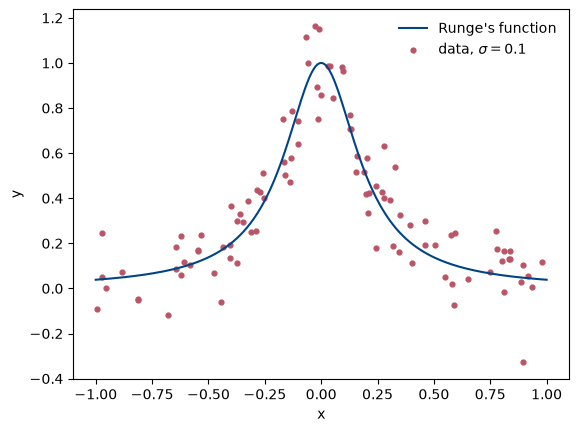

In [83]:
##a)

import numpy as np
import matplotlib.pyplot as plt

def runge(x):
    return 1.0 / (1.0 + 25.0 * x**2)

def design_matrix(x, degree, intercept=True):
    # polynomial features [1, x, x^2, ..., x^degree] (drop the 1 if intercept=False)
    start = 0 if intercept else 1
    return np.vstack([x**p for p in range(start, degree + 1)]).T

#Creating the dataset
rng = np.random.default_rng(2026)
n = 100
sigma = 0.1                               # noise level: explore it!
x = np.sort(rng.uniform(-1, 1, n))
y = runge(x) + rng.normal(0, sigma, n)

#Show the runge function along with the datapoints
xx = np.linspace(-1, 1, 400)
plt.plot(xx, runge(xx), color="#004488", label="Runge's function")
plt.scatter(x, y, s=12, color="#BB5566", label=rf"data, $\sigma={sigma}$")
plt.xlabel("x"); plt.ylabel("y"); plt.legend(frameon=False)
plt.show()




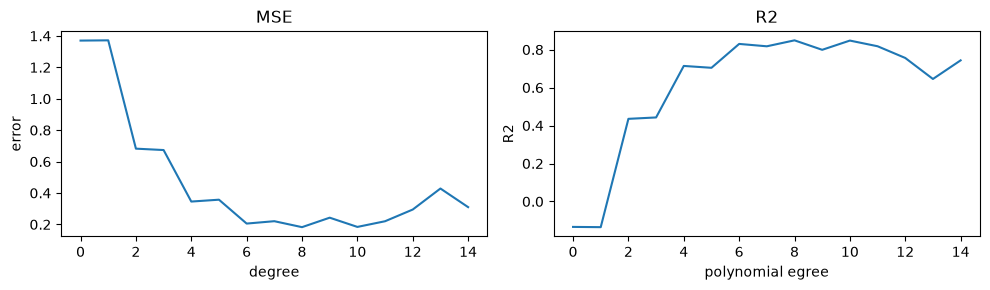

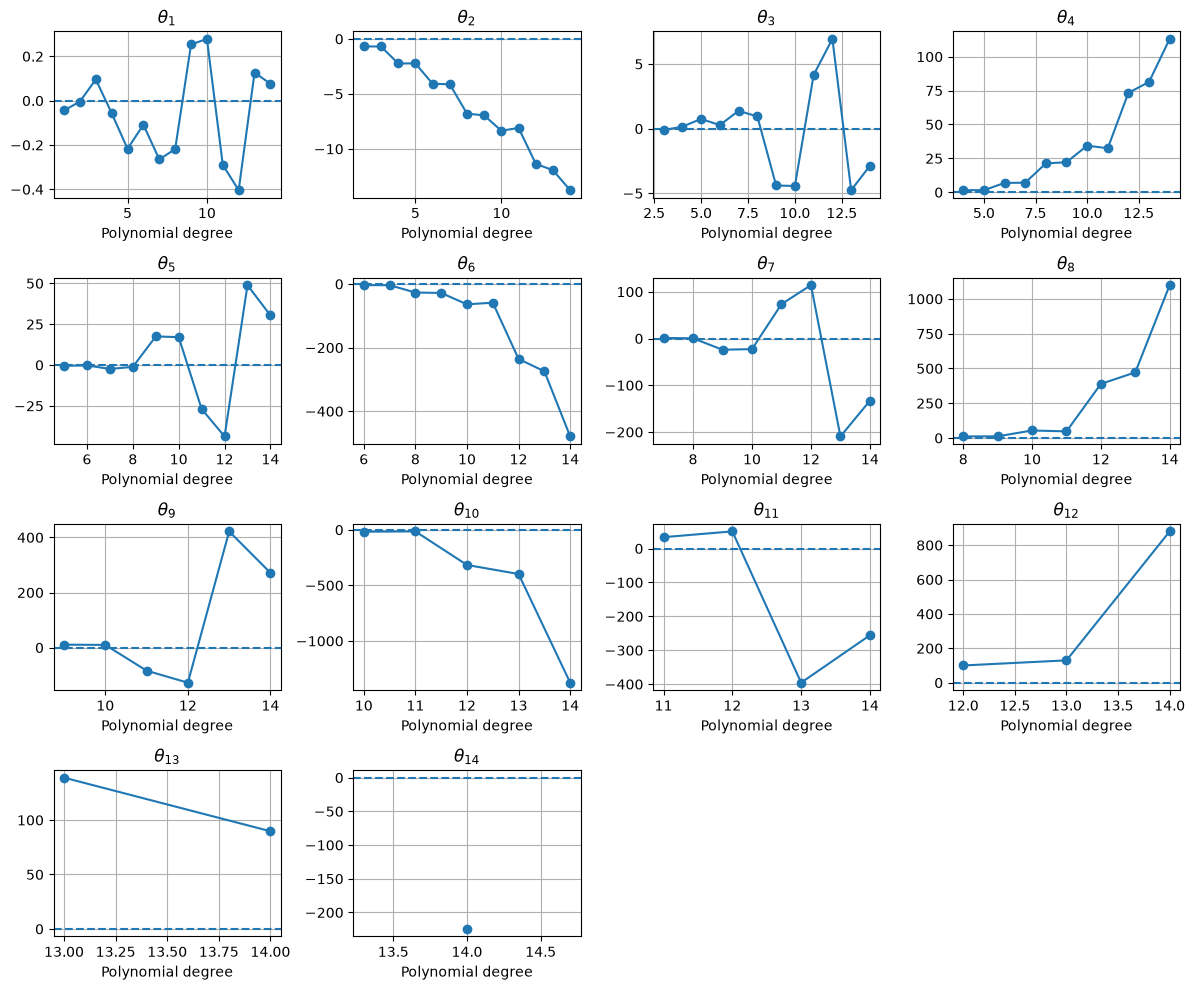

MSE coeffs polynomial degree 5: [-0.020156102051171566, -0.21725503045423158, -2.2266958782468094, 0.7504325845647202, 1.5673192141652652, -0.4540749631354588]


In [84]:
from sklearn.model_selection import train_test_split

#Defining the max degree polynomial
maxdegree = 15

#list of the polynomial degrees to iterate through
degrees = np.arange(maxdegree)

#MSE to each polynomial tested
MSE = np.zeros(maxdegree)

#R2 score to each polynomial tested
R2 = np.zeros(maxdegree)

#list of the coefficients for each polynomial
coeffs = [np.zeros(maxdegree-i) for i in range(maxdegree)]

#scaling the data:
y_std = (y-np.mean(y))/np.sqrt(np.var(y))


for degree in degrees:
    #creating scaled data for the polynomial
    X = design_matrix(x, degree)
    X_mean = X - np.mean(X, axis = 0, keepdims = True)
    X_std = np.empty((n, degree+1))
    X_std[:,1:] = X_mean[:,1:]/np.sqrt(np.var(X_mean[:,1:], axis = 0, keepdims = True))
    X_std[:,0] = np.ones(n)

    #Splitting data into train and test data:
    Xtrain, Xtest, Ytrain, Ytest = train_test_split(X_std, y_std, test_size=0.2, random_state= 2026)

    #Initialise coefficient array
    coeff = np.zeros(degree+1)

    #SVD decomposition of the traning data
    U, s, Vt = np.linalg.svd(Xtrain)

    #Finding the coefficients
    s_inv = np.zeros((degree+1,len(Ytrain)))
    s_inv[:,:degree+1] += np.diag(1/s)
    coeff = Vt.T@s_inv@U.T@Ytrain

    #Record the coefficients
    for i in range(degree+1):
        coeffs[i][degree-i] = coeff[i]

    #Predicting the data
    y_pred = Xtest@coeff

    #Finding the MSE and R2
    y_mean = np.mean(Ytest)
    MSE[degree] = np.mean((y_pred-Ytest)**2)
    R2[degree] = 1-np.mean((y_pred-Ytest)**2)/np.mean((Ytest-y_mean)**2)

#Plotter MSE og R2
fig, axes = plt.subplots(1, 2, figsize=(10, 3))
axes[0].plot(degrees,MSE)
axes[0].set_title("MSE")
axes[0].set_xlabel("degree")
axes[0].set_ylabel("error")

axes[1].plot(degrees,R2)
axes[1].set_title("R2")
axes[1].set_xlabel("polynomial egree")
axes[1].set_ylabel("R2")

plt.tight_layout()
plt.plot()
plt.show()


#plotter koeffesientene unntat intercept fordi det er alltid 0
#----!!! KODE her laget av ChatGPT !!!----:
# Plot each coefficient separately
square = int(np.sqrt(maxdegree))+1
fig, axes = plt.subplots(
    square, square,
    figsize=(12, 10)
)

axes = axes.flatten()

for i in range(1, maxdegree):
    degrees_i = np.arange(i, maxdegree)

    axes[i - 1].plot(
        degrees_i,
        coeffs[i],
        marker="o",
        linestyle="-"
    )

    axes[i - 1].axhline(0, linestyle="--")

    axes[i - 1].set_title(rf"$\theta_{{{i}}}$")
    axes[i - 1].set_xlabel("Polynomial degree")
    axes[i - 1].grid(True)

# Hide the unused subplot
for j in range(maxdegree - 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()
#----------------------------------------
#printer koeffesientene som skal sammenliknes med GD:
coeffs_degree_5 = [float(coeffs[i][5-i]) for i in range(6)]
print("MSE coeffs polynomial degree 5:", coeffs_degree_5)


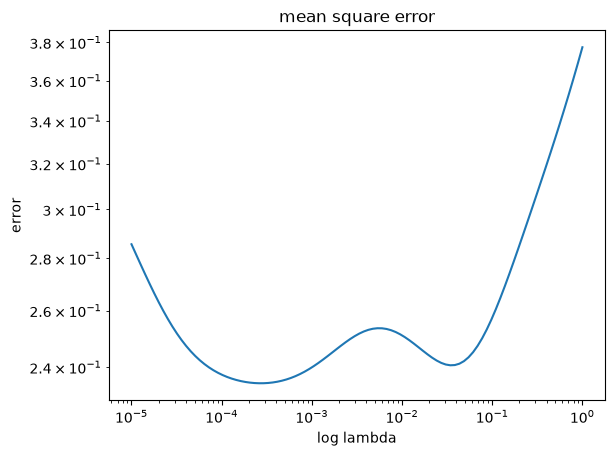

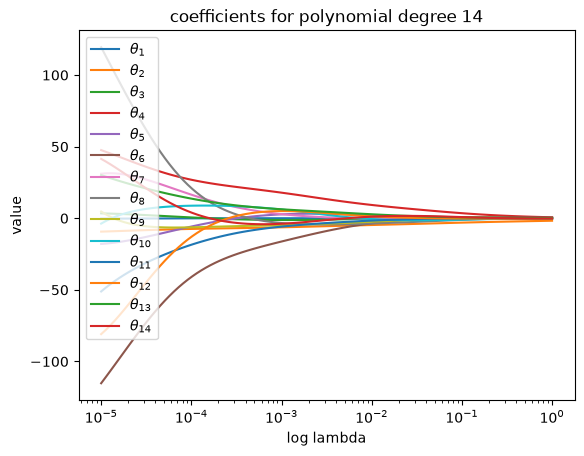

min mse:  0.23459578689191513
lambda:  0.00025950242113997375


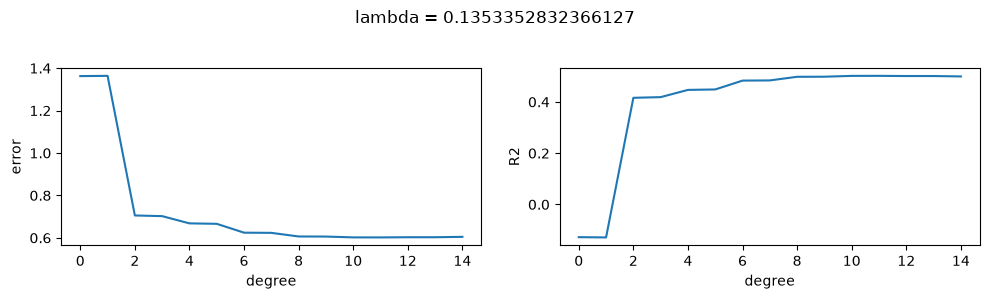

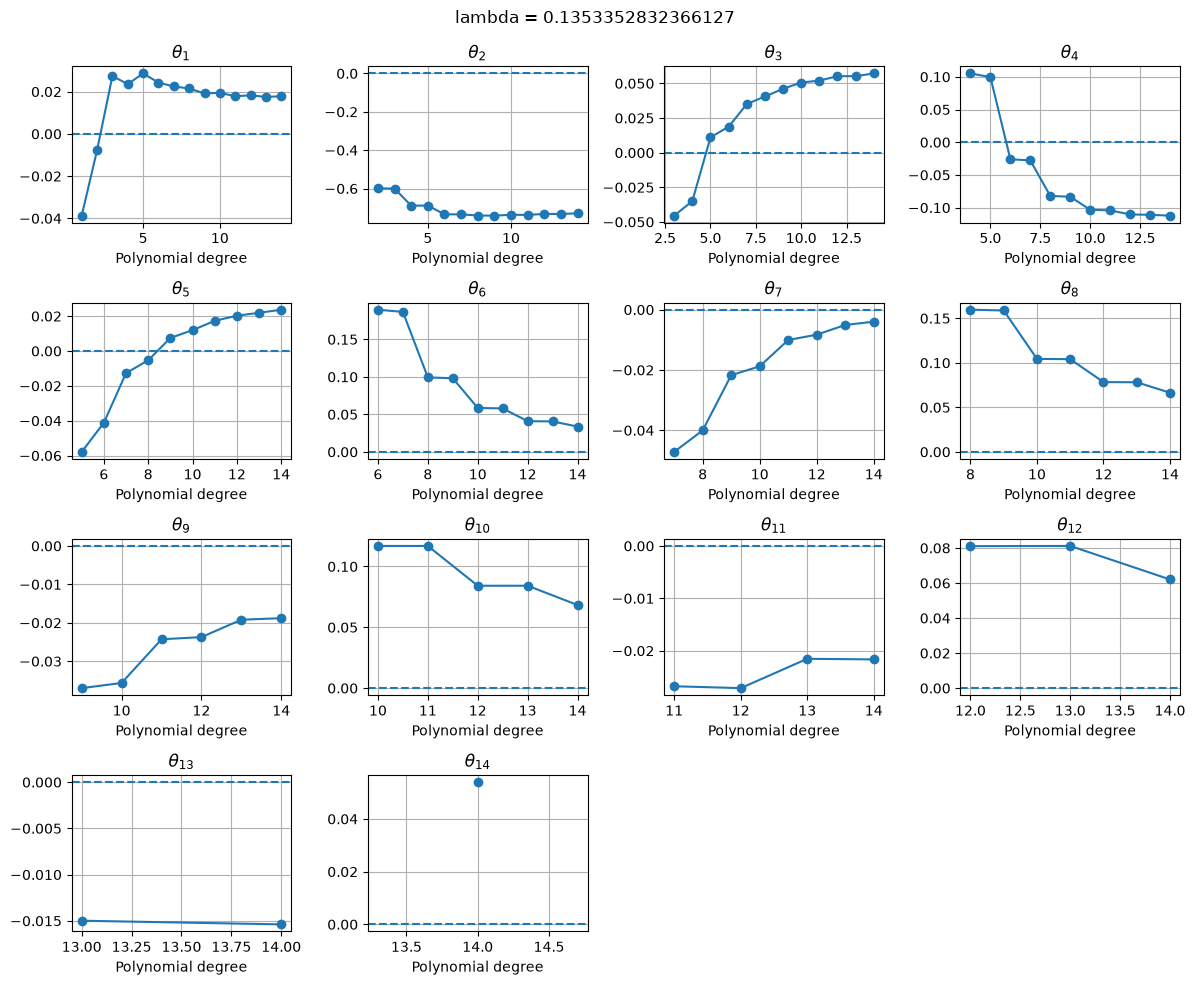

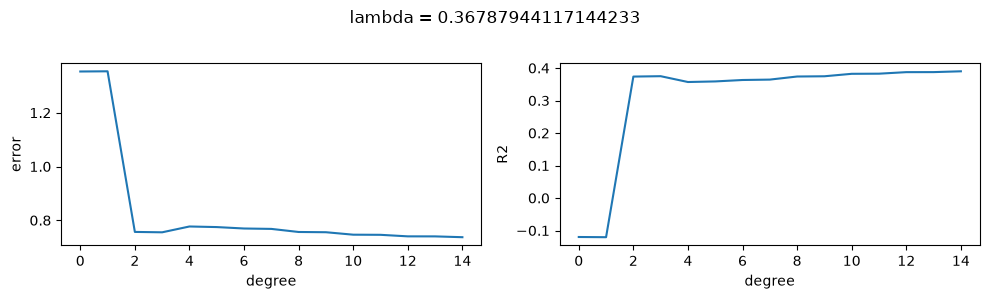

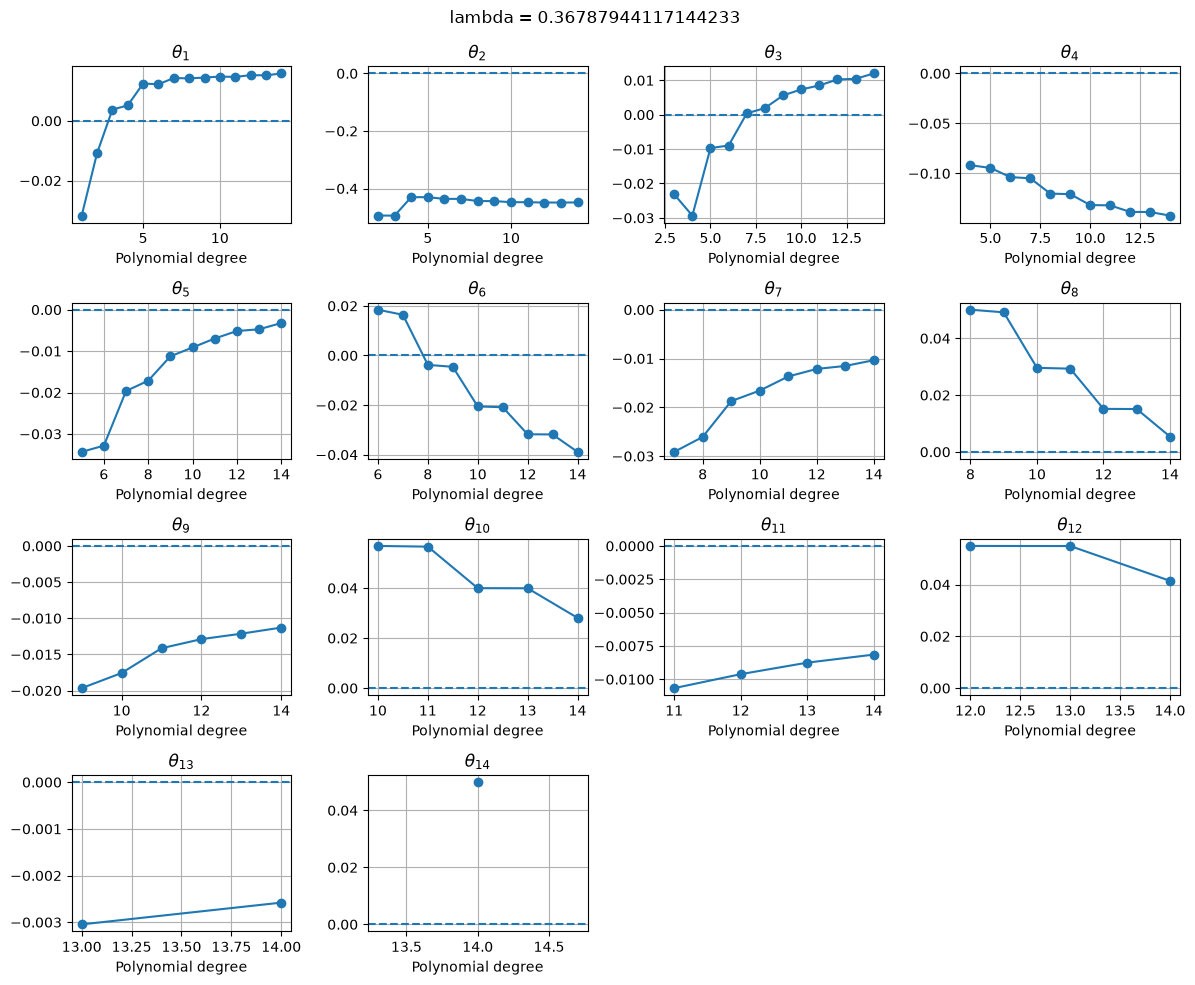

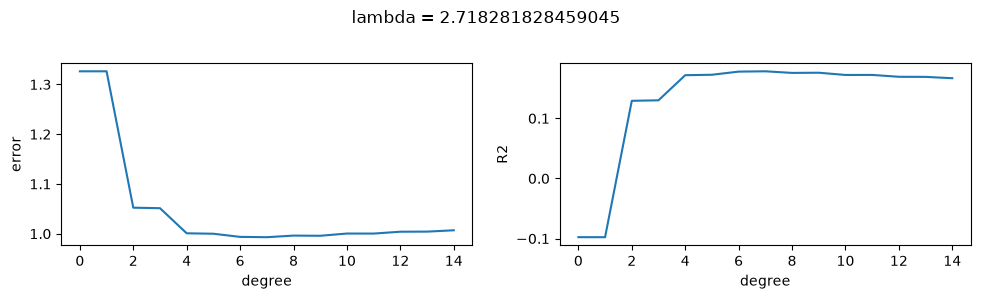

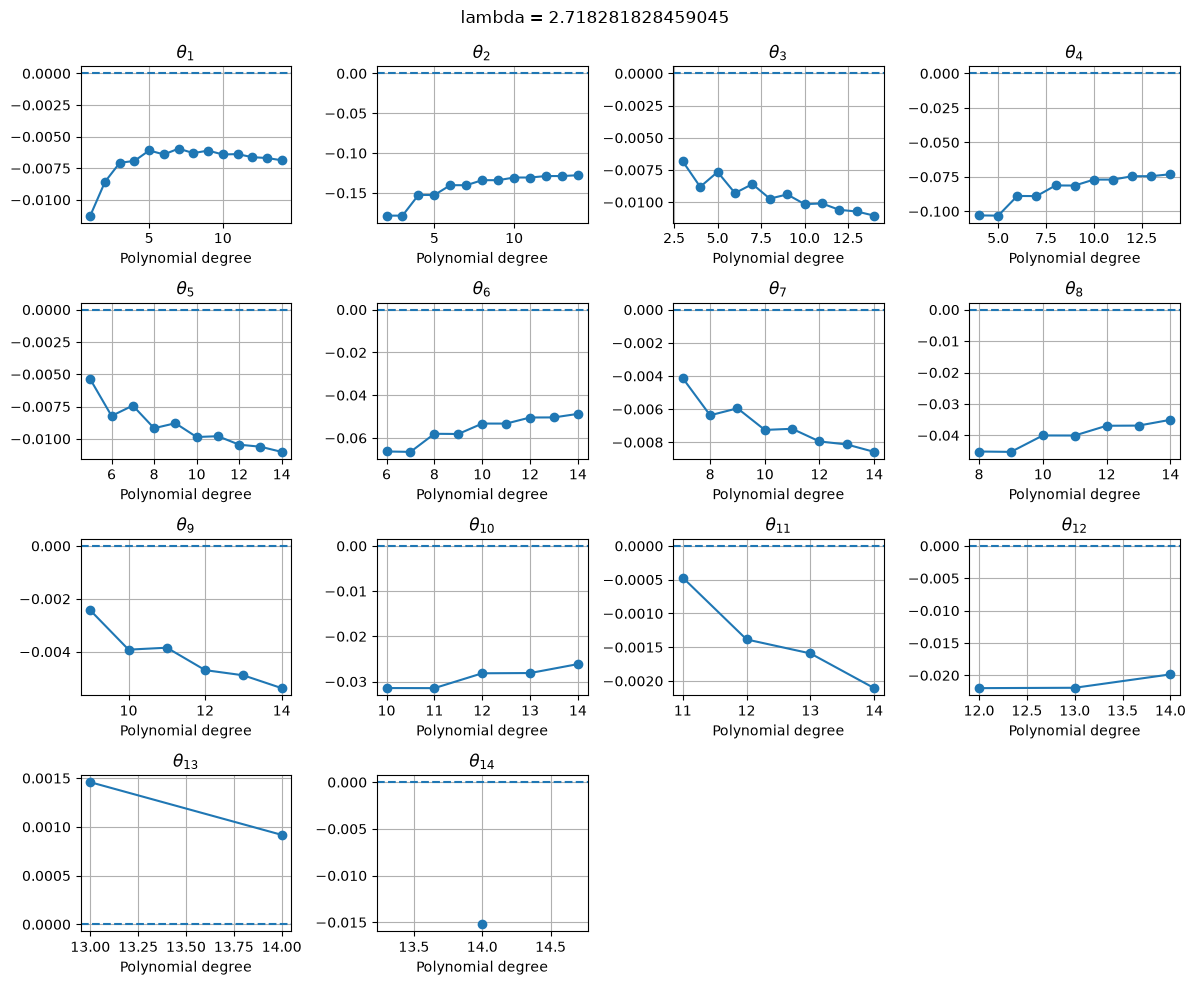

[ 0.01587233  0.02862224 -0.6885043   0.01109006  0.09957797 -0.05788124]


In [85]:
#b
n = 100

#Setting maxdegree
degree = 14

#Creating scaled data:
X = design_matrix(x, degree)
X_mean = X - np.mean(X, axis = 0, keepdims = True)
X_std = np.empty((n, degree+1))
X_std[:,1:] = X_mean[:,1:]/np.sqrt(np.var(X_mean[:,1:], axis = 0, keepdims = True))
X_std[:,0] = np.ones(n)

#Splitting into test and train data
Xtrain, Xtest, Ytrain, Ytest = train_test_split(X_std, y_std, test_size=0.2, random_state=2026)

#The number of traning data samples
n_train = len(Xtrain[:,0])

#Creating the lambdas
lambda_num = 100
lam_borders = -5,0
lam = np.logspace(lam_borders[0], lam_borders[1], lambda_num)

#initialize the MSE and R2
MSE = np.zeros(lambda_num)
R2  = np.zeros(lambda_num)

#initialise coefficient list
coeffs = np.zeros((lambda_num, degree+1))

for l in range(lambda_num):
    #find coefficients
    inv_mat = Xtrain.T@Xtrain+np.identity(degree+1)*lam[l]
    coeff = np.linalg.solve(inv_mat, Xtrain.T@Ytrain)

    #predicting the test data
    y_pred = Xtest@coeff

    coeffs[l] = coeff

    #Record MSE and R2
    y_mean = np.mean(Ytest)
    MSE[l] = np.mean((y_pred-Ytest)**2)
    R2[l] = 1-np.mean((y_pred-Ytest)**2)/np.mean((Ytest-y_mean)**2)

#Plot the mean square error
plt.plot(lam, MSE)
plt.title("mean square error")
plt.ylabel("error")
plt.xlabel("log lambda")
plt.yscale("log")
plt.xscale("log")
plt.show()

#Plot the coefficients
for i in range(1,degree+1):
    plt.plot(lam, coeffs[:,i])
plt.title("coefficients for polynomial degree 14")
plt.ylabel("value")
plt.xlabel("log lambda")
plt.xscale("log")
plt.legend([r"$\theta_{"+str(i+1)+"}$" for i in range(degree)])
plt.show()

print("min mse: ",np.min(MSE))
print("lambda: ",lam[np.argmin(MSE)])


#Setting the maxdegree of the polynomials for Ridge regression
maxdegree = 15
degrees = np.arange(maxdegree)

#Create the lambda values
loglambdas = np.array([-2,-1,1])
lambdas = np.exp(loglambdas)

#These coefficients will be printed out to compare with gradient descent
recorded_coeff = np.zeros(6)

for j,l in enumerate(lambdas):
    
    #initialize the MSE, R2 arrays
    MSE = np.zeros(maxdegree)
    R2 = np.zeros(maxdegree)

    #initialize the coefficient arrays
    coeffs = [np.zeros(maxdegree-i) for i in range(maxdegree)]

    #scale the y data
    y_std = (y-np.mean(y))/np.sqrt(np.var(y))


    for degree in degrees:
        
        #Create X data for the polynomial degrees
        X = design_matrix(x, degree)
        X_mean = X - np.mean(X, axis = 0, keepdims = True)
        X_std = np.empty((n, degree+1))
        X_std[:,1:] = X_mean[:,1:]/np.sqrt(np.var(X_mean[:,1:], axis = 0, keepdims = True))
        X_std[:,0] = np.ones(n)

        #Split the data into training and test set
        Xtrain, Xtest, Ytrain, Ytest = train_test_split(X_std, y_std, test_size=0.2, random_state=2026)

        #Find the coefficients
        coeff = np.linalg.solve(Xtrain.T@Xtrain+np.identity(degree+1)*l*n_train, Xtrain.T@Ytrain)

        #predict the test data
        y_pred = Xtest@coeff

        for i in range(degree+1):
            coeffs[i][degree-i] = coeff[i]

        #Find the MSE and R2 scores
        y_mean = np.mean(Ytest)
        MSE[degree] = np.mean((y_pred-Ytest)**2)
        R2[degree] = 1-np.mean((y_pred-Ytest)**2)/np.mean((Ytest-y_mean)**2)

        #Record the coefficients to be compared with gradient descent
        if degree == 5 and j == 0:
            recorded_coeff = coeff


    #plot the MSE and R2 scores
    fig, axes = plt.subplots(1, 2, figsize=(10, 3))
    axes[0].plot(degrees,MSE)
    axes[0].set_xlabel("degree")
    axes[0].set_ylabel("error")

    axes[1].plot(degrees,R2)
    axes[1].set_xlabel("degree")
    axes[1].set_ylabel("R2")

    fig.suptitle("lambda = "+str(l))#<---- Disse to linjene er fra ChatGPT
    plt.tight_layout(rect=[0, 0, 1, 0.96]) #<--- og her
    plt.plot()
    plt.show()


    #plotter koeffesientene unntat intercept fordi det er alltid 0
    #----!!! KODE her laget av ChatGPT !!!----:
    # Plot each coefficient separately
    square = int(np.sqrt(maxdegree))+1
    fig, axes = plt.subplots(
        square, square,
        figsize=(12, 10)
    )

    axes = axes.flatten()

    for i in range(1, maxdegree):
        degrees_i = np.arange(i, maxdegree)

        axes[i - 1].plot(
            degrees_i,
            coeffs[i],
            marker="o",
            linestyle="-"
        )

        axes[i - 1].axhline(0, linestyle="--")

        axes[i - 1].set_title(rf"$\theta_{{{i}}}$")
        axes[i - 1].set_xlabel("Polynomial degree")
        axes[i - 1].grid(True)

    # Hide the unused subplot
    for j in range(maxdegree - 1, len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    fig.suptitle("lambda = "+str(l))
    plt.show()
    #----------------------------------------
print(recorded_coeff)



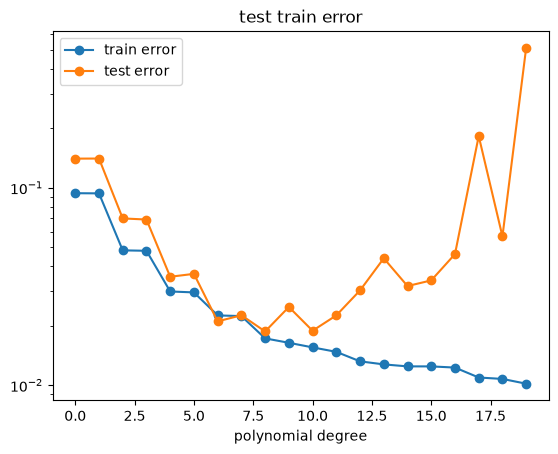

In [86]:
#c
#Split the data into training and test set
xtrain, xtest, ytrain, ytest = train_test_split(x,y,test_size=0.2, random_state=2026)
from sklearn.metrics import mean_squared_error

#Set maxdegree of the polynomial
maxdegree = 20

#initialize the error arrays
train_error = np.zeros(maxdegree)
test_error = np.zeros(maxdegree)

for degree in range(maxdegree):
    #Create training data. We don't need to scale it because we're just usin OLS here.
    Xtrain = design_matrix(xtrain, degree)

    #Find the coefficients
    coeff = np.zeros(degree+1)
    U, s, Vt = np.linalg.svd(Xtrain)
    s_inv = np.zeros((degree+1,len(Ytrain)))
    s_inv[:,:degree+1] += np.diag(1/s)
    coeff = Vt.T@s_inv@U.T@ytrain #<-- ChatGPT fikset en bug her, der jeg hadde skrevet Ytrain i stedet.

    #Finding the predicted values for train and test data
    Xtest = design_matrix(xtest, degree)
    y_pred_test = Xtest@coeff
    y_pred_train = Xtrain@coeff

    #Finding the error
    test_error[degree] = mean_squared_error(y_pred_test, ytest)
    train_error[degree] = mean_squared_error(y_pred_train, ytrain)

#Plotting the errors:
degrees = np.arange(maxdegree)
plt.plot(degrees, train_error, marker = "o", linestyle ="-")
plt.plot(degrees, test_error, marker = "o", linestyle = "-")
plt.legend(["train error", "test error"])
plt.xlabel("polynomial degree")
plt.yscale("log")
plt.title("test train error")
plt.show()



$$
\mathbb{E}((y-\tilde{y})^2) = \mathbb{E}((y-\mathbb{E}(\tilde{y}))-(\tilde{y}-\mathbb{E}(\tilde{y}))^2)\\
=\mathbb{E}((y-\mathbb{E}(\tilde{y}))^2)+\mathbb{E}((\tilde{y}-\mathbb{E}(\tilde{y}))^2)+2\mathbb{E}((y-\mathbb{E}(\tilde{y}))(\tilde{y}-\mathbb{E}(\tilde{y}))=\\ \mathbb{E}((y-\mathbb{E}(\tilde{y}))^2)+\mathbb{E}((\tilde{y}-\mathbb{E}(\tilde{y}))^2)+2\mathbb{E}(y-\mathbb{E}(\tilde{y}))\mathbb{E}(\tilde{y}-\mathbb{E}(\tilde{y}))=\\ \mathbb{E}((y-\mathbb{E}(\tilde{y}))^2)+\mathbb{E}((\tilde{y}-\mathbb{E}(\tilde{y}))^2)+2\mathbb{E}(y-\mathbb{E}(\tilde{y}))(\mathbb{E}(\tilde{y})-\mathbb{E}(\tilde{y}))=\mathbb{E}((y-\mathbb{E}(\tilde{y}))^2)+\mathbb{E}((\tilde{y}-\mathbb{E}(\tilde{y}))^2)
$$
Jeg ser nå på $\mathbb{E}((y-\mathbb{E}(\tilde{y}))^2)$:

$$
\mathbb{E}((y-\mathbb{E}(\tilde{y}))^2)=\mathbb{E}((f+\epsilon-\mathbb{E}[\tilde{y}])^2)=\mathbb{E}[(f-\mathbb{E}[\tilde{y}])^2+\epsilon^2+2\epsilon(f-\mathbb{E}[\tilde{y}])] =\\ \mathbb{E}[(f-\mathbb{E}[\tilde{y}])^2]+\mathbb{E}[\epsilon^2]+2\mathbb{E}[\epsilon(f-\mathbb{E}[\tilde{y}])]=\mathbb{E}[(f-\mathbb{E}[\tilde{y}])^2]+\mathbb{E}[\epsilon^2]+2\mathbb{E}[\epsilon]\mathbb{E}[(f-\mathbb{E}[\tilde{y}])]=\\
\mathbb{E}[(f-\mathbb{E}[\tilde{y}])^2]+\mathbb{E}[\epsilon^2]=\mathbb{E}[(f-\mathbb{E}[\tilde{y}])^2]+\sigma^2
$$

Hvis jeg nå setter alt sammen:
$$
\mathbb{E}((y-\mathbb{E}(\tilde{y}))^2)=\mathbb{E}((\tilde{y}-\mathbb{E}(\tilde{y}))^2)+\mathbb{E}[(f-\mathbb{E}[\tilde{y}])^2]+\sigma^2 \\ =\frac{1}{n}\sum_i(f_i-\mathbb{E}(\tilde{y}))^2+\frac{1}{n}\sum_i(\tilde{y}_i-\mathbb{E}(\tilde{y}))^2+\sigma^2
$$

Jeg ser på hva som skjer om man erstatter f med y i bias leddet:

$$
\mathbb{E}[((y_{test})-\tilde{y})^2] = \mathbb{E}[(f+\sigma+\tilde{y})]^2 =\\ \mathbb{E}[(f+\tilde{y})^2]+\mathbb{E}[\sigma^2]+2\mathbb{E}[(f+\tilde{y})\sigma] = \mathbb{E}[(f+\tilde{y})^2]+E[\sigma^2]+2E[(f+\tilde{y})]\mathbb{E}[\sigma] =  \mathbb{E}[(f+\tilde{y})^2]+\sigma^2
$$

Dermed kan man se at Bias slik den er definert med $y_{test}$ i stedet for $f$ blir større på grunn av $\sigma$, så den printete identiteten kommer er ikke lik i teorien.

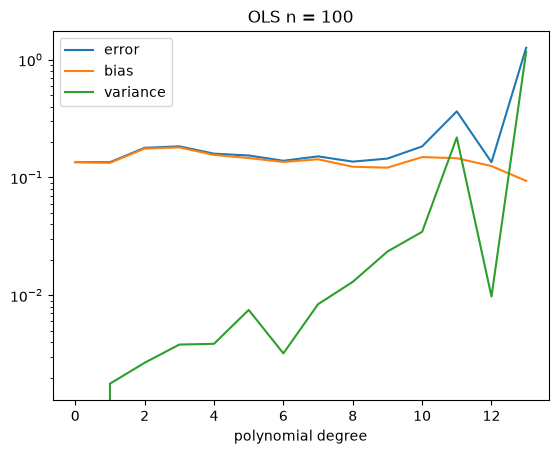

min error:  0.13463322802036304
degree with min error:  12


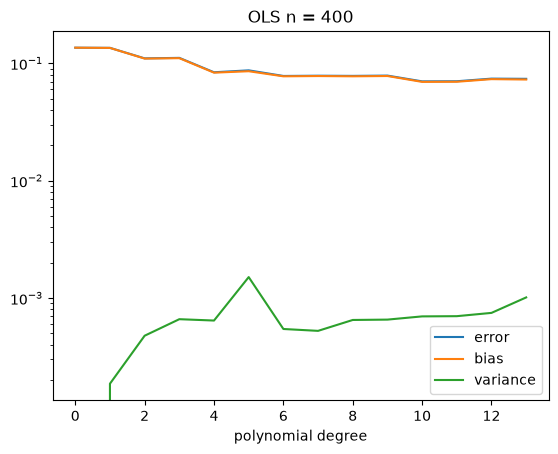

min error:  0.07021339388724261
degree with min error:  10


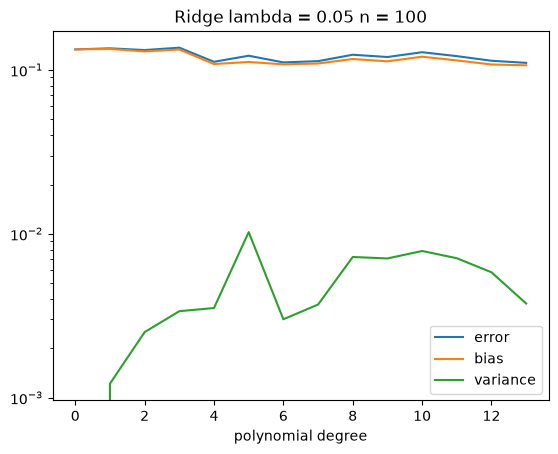

min error:  0.11053619739220948
degree with min error:  13


In [87]:
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.utils import resample

np.random.seed(2026)

#This program make three plots, one with 100 datapoints with OLS, one with 400 datapoints with OLS and one with 100 datapoints with Ridge
ns = [100, 400, 100]
methods = [LinearRegression(fit_intercept=False), LinearRegression(fit_intercept=False), Ridge(alpha= 0.05, fit_intercept=False)]
method_titles = ["OLS", "OLS", "Ridge lambda = 0.05"]

#Setting the number of bootstraps and the maximum degree
n_bootstraps, maxdegree = 100, 14

for n, method, method_title in zip(ns, methods, method_titles):
    #Making the data:
    x = np.sort(rng.uniform(-1, 1, n))
    y = runge(x) + rng.normal(0, sigma, n)

    #Splitting the data into training and test set.
    x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2, random_state= 2026)

    x_train = x_train.reshape(-1,1)
    x_test = x_test.reshape(-1,1)

    #initialising the error, bias and variance
    error = np.zeros(maxdegree)
    bias = np.zeros(maxdegree)
    variance = np.zeros(maxdegree)

    for deg in range(maxdegree):
        #Making the model
        model = make_pipeline(PolynomialFeatures(degree=deg), StandardScaler(), method)#<-ChatGPT hjalp med å finne StandardScaler for å normalisere data.

        #Making bootstrapped predictions from samples of the traning set.
        y_pred = np.empty((len(y_test), n_bootstraps))
        for i in range(n_bootstraps):
            x_, y_ = resample(x_train, y_train)
            y_pred[:,i] = model.fit(x_,y_).predict(x_test).ravel()

        #Add the error, bias and variance
        error[deg] = np.mean(np.mean((y_test[:, None]-y_pred)**2, axis = 1))#<- ChatGPT fikset indekserings feil
        bias[deg] = np.mean((y_test - np.mean(y_pred, axis = 1))**2)#<- ChatGPT fikset indekseringsfeil her.
        variance[deg] = np.mean(np.var(y_pred, axis = 1))
        
    #plot the error, bias and variance
    x_axis = np.arange(maxdegree)
    plt.yscale("log")
    plt.title(method_title+" n = "+str(n))
    plt.plot(x_axis, error)
    plt.plot(x_axis, bias)
    plt.plot(x_axis, variance)
    plt.xlabel("polynomial degree")
    plt.legend(["error","bias", "variance"])


    plt.show()
    print("min error: ",np.min(error))
    print("degree with min error: ",np.argmin(error))


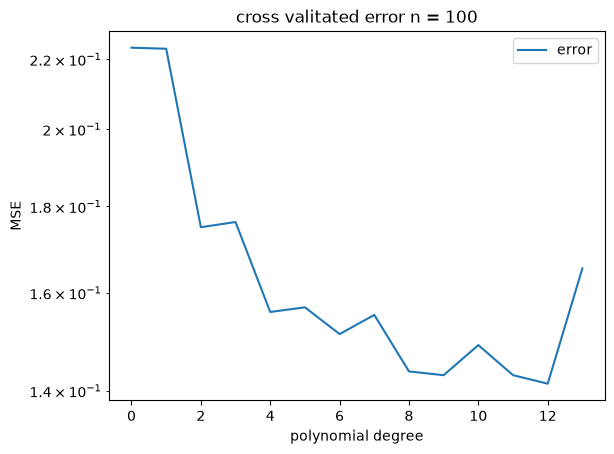

min error:  0.14136028810765916
degree with min error:  12


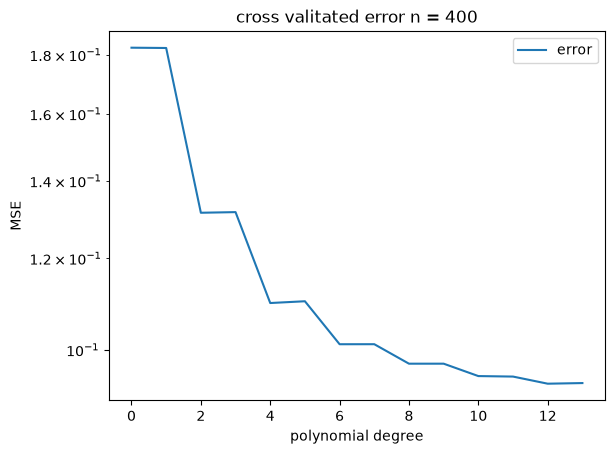

min error:  0.09346651955505805
degree with min error:  12


In [88]:
#d
from sklearn.model_selection import train_test_split, KFold, cross_val_score

rng = np.random.default_rng(2026)

#Set parameters:
ns = [100,400] #The number of datapoints to use
maxdegree = 14 #the maximum degree polynomial to use
splits = 10    #The number of splits in the k fold cross validation

for n in ns:
    #Create the data
    x = np.sort(rng.uniform(-1, 1, n))
    y = runge(x) + rng.normal(0, sigma, n)

    #Split into folds
    kf = KFold(n_splits = splits, shuffle = True, random_state=2026)

    MSE = np.zeros(maxdegree)

    for deg in range(maxdegree):
        mse = np.zeros(splits)

        #Create the model.
        model = make_pipeline(PolynomialFeatures(degree = deg), StandardScaler(), LinearRegression(fit_intercept= False))

        #Iterate through the folds
        for i, (train_idx, test_idx) in enumerate(kf.split(x)):
            y_pred = model.fit(x.reshape(-1,1)[train_idx], y[train_idx]).predict(x.reshape(-1,1)[test_idx])
            y_test = y[test_idx]

            mse[i] = np.mean((y_pred-y_test)**2)

        #Store the MSE
        MSE[deg] = np.mean(mse)

    #Plot the error:
    x_axis = np.arange(maxdegree)
    plt.yscale("log")
    plt.title("cross valitated error n = "+str(n))
    plt.plot(x_axis, MSE)
    plt.ylabel("MSE")
    plt.legend(["error"])
    plt.xlabel("polynomial degree")

    plt.show()
    print("min error: ",np.min(MSE))
    print("degree with min error: ",np.argmin(MSE))

In [89]:
#Gradients:
#This was taken from the project task page:
import jax
import jax.numpy as jnp
jax.config.update("jax_enable_x64", True)   # 64-bit floats, as in numpy
from jax import grad

degree, lmbda = 5, 1e-2
X = design_matrix(x, degree)
theta0 = rng.normal(size=X.shape[1])

def cost_ols(theta, X, y):
    return jnp.mean((y - X @ theta)**2)

def cost_ridge(theta, X, y, lmbda):
    return jnp.mean((y - X @ theta)**2) + lmbda * jnp.sum(theta**2)

# gradients by automatic differentiation (with respect to argument 0 = theta)
grad_ols_ad = jax.grad(cost_ols)
grad_ridge_ad = jax.grad(cost_ridge)

# the same gradients by hand
grad_ols_analytic = 2.0 / len(y) * X.T @ (X @ theta0 - y)
grad_ridge_analytic = grad_ols_analytic + 2.0 * lmbda * theta0

print("OLS   max |AD - analytic| =", np.max(np.abs(grad_ols_ad(theta0, X, y) - grad_ols_analytic)))
print("Ridge max |AD - analytic| =", np.max(np.abs(grad_ridge_ad(theta0, X, y, lmbda) - grad_ridge_analytic)))

# the largest safe learning rate for plain gradient descent: eta < 2 / lambda_max(Hessian)
H = 2.0 / len(y) * X.T @ X
print("eta_max for OLS  =", 2.0 / np.linalg.eigvalsh(H).max())
n=n

OLS   max |AD - analytic| = 2.220446049250313e-16
Ridge max |AD - analytic| = 2.220446049250313e-16
eta_max for OLS  = 0.8509872411656054


In [90]:
#e
#This code calculates the gradients to find what the coefficients are
#and how many iterations it takes to converge to the closed form solution.

n=100 #<- ChatGPT fikset koden med å flytte n
rng = np.random.default_rng(2026)
x = np.sort(rng.uniform(-1, 1, n))
y = runge(x) + rng.normal(0, sigma, n)

X = design_matrix(x, degree)

X_mean = X - np.mean(X, axis = 0, keepdims = True)
X_std = np.empty((n, degree+1))
X_std[:,1:] = X_mean[:,1:]/np.sqrt(np.var(X_mean[:,1:], axis = 0, keepdims = True))
X_std[:,0] = np.ones(n)

Xtrain, Xtest, Ytrain, Ytest = train_test_split(X_std, y_std, test_size=0.2, random_state= 2026)

X_norm5 = Xtrain


n_train = len(X_norm5[:,0])

n_features5 = X_norm5.shape[1]

Hessian = (2/n_train)*X_norm5.T@X_norm5
eig = np.linalg.eigvalsh(Hessian)
gamma_opt = 2/(eig[0]+eig[-1])


# Gradient descent parameters, learning rate gamma first
# Then the maximum number of iterations, and a tolerance for the stopping criterion
num_iters = 100000
tol = 1e-8 #<-ChatGPT fikset stoppe kriteriet
lam = np.exp(-2)


# Initialize weights for gradient descent

recorded_theta_OLS = np.zeros(n_features5)

#OLS
# Gradient descent loop
gamma = gamma_opt

theta_gdOLS = np.zeros(n_features5)
for t in range(num_iters):

    # Compute gradients for OLS and Ridge
    grad_OLS = (2/n_train)*X_norm5.T@(X_norm5@theta_gdOLS - Ytrain)

    # Update parameters theta
    theta_gdOLS = theta_gdOLS - gamma_opt*grad_OLS
    if np.linalg.norm(grad_OLS)<tol:
        break

actual_iters_OLS = t

#Ridge:
Hessian_Ridge = (2/n_train)*X_norm5.T@X_norm5+2*lam*np.identity(n_features5)
eig_Ridge = np.linalg.eigvalsh(Hessian_Ridge)
gamma_opt_Ridge = 2/(eig_Ridge[0]+eig_Ridge[-1])


# Gradient descent loop
theta_gdRidge = np.zeros(n_features5)
for t in range(num_iters):

    # Compute gradients for OLS and Ridge
    grad_Ridge = (2/n_train)*X_norm5.T@(X_norm5@theta_gdRidge - Ytrain) + 2*lam*theta_gdRidge
    
    # Update parameters theta
    theta_gdRidge = theta_gdRidge - gamma_opt_Ridge*grad_Ridge
    if np.linalg.norm(grad_Ridge)<tol:
        break

actual_iters_Ridge = t


print("OLS:")
print("theta:", theta_gdOLS)
print("iterations for gamma: ",int(actual_iters_OLS))
print("condition number: ", (eig[-1]/eig[0]))
print("min eig: ",eig[0]," max eig: ", eig[-1])
print("")
print("Ridge")
print("theta:", theta_gdRidge)
print("iterations for gamma: ",int(actual_iters_Ridge))
print("condition number: ", (eig_Ridge[-1]/eig_Ridge[0]))
print("min eig: ",eig_Ridge[0]," max eig: ", eig_Ridge[-1])

OLS:
theta: [-0.0201561  -0.21725501 -2.22669588  0.75043252  1.56731922 -0.45407491]
iterations for gamma:  3952
condition number:  491.41312071818305
min eig:  0.010358962240372332  max eig:  5.090529961943189

Ridge
theta: [ 0.01587233  0.02862224 -0.6885043   0.01109006  0.09957797 -0.05788124]
iterations for gamma:  154
condition number:  19.077000744217575
min eig:  0.2810295287135975  max eig:  5.361200528416413


In [91]:
#e jax
#This code calculates the gradients using jax to find what the coefficients are
#and how many iterations it takes to converge to the closed form solution.
n=100

#Create scaled data:
rng = np.random.default_rng(2026)
x = np.sort(rng.uniform(-1, 1, n))
y = runge(x) + rng.normal(0, sigma, n)

X = design_matrix(x, degree)

print(np.shape(X))
X_mean = X - np.mean(X, axis = 0, keepdims = True)
X_std = np.empty((n, degree+1))
X_std[:,1:] = X_mean[:,1:]/np.sqrt(np.var(X_mean[:,1:], axis = 0, keepdims = True))
X_std[:,0] = np.ones(n)

Xtrain, Xtest, Ytrain, Ytest = train_test_split(X_std, y_std, test_size=0.2, random_state= 2026)

X_norm5 = Xtrain
n_train = len(X_norm5[:,0])
n_features5 = X_norm5.shape[1]

#create eigenvalues and optimal gamma.
Hessian = (2/n_train)*X_norm5.T@X_norm5
eig = np.linalg.eigvalsh(Hessian)
gamma_opt = 2/(eig[0]+eig[-1])


# Gradient descent parameters, learning rate gamma first
# Then the maximum number of iterations, and a tolerance for the stopping criterion
num_iters = 5000
tol = 1e-8 #<-ChatGPT fikset stoppe kriteriet
lam = np.exp(-2)


# Initialize weights for gradient descent


recorded_theta_OLS = np.zeros(n_features5)

#OLS
# Gradient descent loop
gamma = gamma_opt

theta_gdOLS = np.zeros(n_features5)
for t in range(num_iters):

    # Compute gradients for OLS and Ridge
    grad_OLS = grad_OLS = grad(cost_ols)(theta_gdOLS, jnp.asarray(X_norm5), jnp.asarray(Ytrain))

    # Update parameters theta
    theta_gdOLS = theta_gdOLS - gamma_opt*grad_OLS
    if np.linalg.norm(grad_OLS)<tol:
        break

actual_iters_OLS = t

#Ridge:

Hessian_Ridge = (2/n_train)*X_norm5.T@X_norm5+2*lam*np.identity(n_features5)
eig_Ridge = np.linalg.eigvalsh(Hessian_Ridge)
gamma_opt_Ridge = 2/(eig_Ridge[0]+eig_Ridge[-1])


# Gradient descent loop
theta_gdRidge = np.zeros(n_features5)
for t in range(num_iters):

    # Compute gradients for OLS and Ridge
    grad_Ridge = grad(cost_ridge)(theta_gdRidge, jnp.asarray(X_norm5), jnp.asarray(Ytrain), lam)#<- ChatGPT fant bug her, jeg hadde skrevet theta_gdOLS i stedet for Ridge
    
    # Update parameters theta
    theta_gdRidge = theta_gdRidge - gamma_opt_Ridge*grad_Ridge
    if np.linalg.norm(grad_Ridge)<tol:
        break

actual_iters_Ridge = t


print("OLS:")
print("theta:", theta_gdOLS)
print("iterations for gamma: ",int(actual_iters_OLS))
print("condition number: ", (eig[-1]/eig[0]))
print("min eig: ",eig[0]," max eig: ", eig[-1])
print("")
print("Ridge")
print("theta:", theta_gdRidge)
print("iterations for gamma: ",int(actual_iters_Ridge))
print("condition number: ", (eig_Ridge[-1]/eig_Ridge[0]))
print("min eig: ",eig_Ridge[0]," max eig: ", eig_Ridge[-1])

(100, 6)
OLS:
theta: [-0.0201561  -0.21725501 -2.22669588  0.75043252  1.56731922 -0.45407491]
iterations for gamma:  3952
condition number:  491.41312071818305
min eig:  0.010358962240372332  max eig:  5.090529961943189

Ridge
theta: [ 0.01587233  0.02862224 -0.6885043   0.01109006  0.09957797 -0.05788124]
iterations for gamma:  154
condition number:  19.077000744217575
min eig:  0.2810295287135975  max eig:  5.361200528416413


In [92]:
#f
n=100
rng = np.random.default_rng(2026)
x = np.sort(rng.uniform(-1, 1, n))
y = runge(x) + rng.normal(0, sigma, n)

X = design_matrix(x, degree)

X_mean = X - np.mean(X, axis = 0, keepdims = True)
X_std = np.empty((n, degree+1))
X_std[:,1:] = X_mean[:,1:]/np.sqrt(np.var(X_mean[:,1:], axis = 0, keepdims = True))
X_std[:,0] = np.ones(n)

Xtrain, Xtest, Ytrain, Ytest = train_test_split(X_std, y_std, test_size=0.2, random_state= 2026)

X_norm5 = Xtrain


n_train = len(X_norm5[:,0])

n_features5 = X_norm5.shape[1]

Hessian = (2/n_train)*X_norm5.T@X_norm5
eig = np.linalg.eigvalsh(Hessian)
gamma_opt = 2/(eig[0]+eig[-1])

# Gradient descent parameters, learning rate gamma first
# Then the maximum number of iterations, and a tolerance for the stopping criterion
num_iters = 100000
tol = 1e-8 #<-ChatGPT fikset stoppe kriteriet
lam = np.exp(-2)


#OLS:

#Momentum:
gamma = 0.1
beta = 0.9
v = np.zeros(n_features5)
theta_gdOLS = np.zeros(n_features5)
for t in range(1,num_iters+1):
    # Compute gradients for OLS and Ridge
    
    grad_OLS = (2/n_train)*X_norm5.T@(X_norm5@theta_gdOLS - Ytrain)
    v = beta*v + gamma*grad_OLS
    # Update parameters theta
    theta_gdOLS = theta_gdOLS - v
    if np.linalg.norm(grad_OLS)<tol:
        break

actual_iters_OLS_momentum = t

#AdaGrad:
gamma = 0.1
eps = 0.0001
r = np.zeros(n_features5)
theta_gdOLS = np.zeros(n_features5)
for t in range(1,num_iters+1):
    # Compute gradients for OLS and Ridge
    
    grad_OLS = (2/n_train)*X_norm5.T@(X_norm5@theta_gdOLS - Ytrain)
    r = r + grad_OLS**2
    # Update parameters theta
    theta_gdOLS = theta_gdOLS -(gamma*grad_OLS)/np.sqrt(eps+r)
    if np.linalg.norm(grad_OLS)<tol:
        break
actual_iters_OLS_AdaGrad = t

#RMSProp
gamma = 0.1
rho = 0.1
eps = 0.0001
r = np.zeros(n_features5)
theta_gdOLS = np.zeros(n_features5)
for t in range(1,num_iters+1):
    # Compute gradients for OLS and Ridge
    
    grad_OLS = (2/n_train)*X_norm5.T@(X_norm5@theta_gdOLS - Ytrain)
    r = rho*r + (1-rho)*grad_OLS**2
    # Update parameters theta
    theta_gdOLS = theta_gdOLS - gamma*grad_OLS/(np.sqrt(r)+eps) #<- ChatGPT påpekte at jeg hadde skrevet oppdateringen her feil
    if np.linalg.norm(grad_OLS)<tol:
        break

actual_iters_OLS_RMSProp = t

#Adam
gamma = 0.1 #<-ChatGPT fikset at jeg ikke hadde denne linjen
beta1 = 0.9
beta2 = 0.999
eps = 0.0001
theta_gdOLS = np.zeros(n_features5)
m = np.zeros(n_features5)
r = np.zeros(n_features5)
for t in range(1,num_iters+1):
    # Compute gradients for OLS and Ridge
    
    grad_OLS = (2/n_train)*X_norm5.T@(X_norm5@theta_gdOLS - Ytrain)
    m = beta1*m + (1-beta1)*grad_OLS
    r = beta2*r + (1-beta2)*grad_OLS**2

    m_hat = m / (1.0 - beta1**t) 
    r_hat = r / (1.0 - beta2**t)
    theta_gdOLS = theta_gdOLS - gamma*m_hat/(np.sqrt(r_hat)+eps)
    if np.linalg.norm(grad_OLS)<tol:
        break

actual_iters_OLS_Adam = t


#Ridge:

Hessian_Ridge = (2/n_train)*X_norm5.T@X_norm5+2*lam*np.identity(n_features5)
eig_Ridge = np.linalg.eigvalsh(Hessian_Ridge)
gamma_opt_Ridge = 2/(eig_Ridge[0]+eig_Ridge[-1])

# Momentum:
gamma = 0.1
theta_gdRidge = np.zeros(n_features5)
v = np.zeros(n_features5)
for t in range(num_iters):
    # Compute gradients for OLS and Ridge
    grad_Ridge = (2/n_train)*X_norm5.T@(X_norm5@theta_gdRidge - Ytrain) + 2*lam*theta_gdRidge
    v = beta*v + gamma*grad_Ridge
    # Update parameters theta
    theta_gdRidge = theta_gdRidge - v
    if np.linalg.norm(grad_Ridge)<tol:
        break

actual_iters_Ridge = t

#AdaGrad:
gamma = 0.1
eps = 0.0001
r = np.zeros(n_features5)
theta_gdRidge = np.zeros(n_features5)
for t in range(1,num_iters+1):
    # Compute gradients for OLS and Ridge
    
    grad_Ridge = (2/n_train)*X_norm5.T@(X_norm5@theta_gdRidge - Ytrain) + 2*lam*theta_gdRidge
    r = r + grad_Ridge**2
    # Update parameters theta
    theta_gdRidge = theta_gdRidge -(gamma*grad_Ridge)/np.sqrt(eps+r)
    if np.linalg.norm(grad_Ridge)<tol:
        break
actual_iters_Ridge_AdaGrad = t

#RMSProp
gamma = 0.1
rho = 0.1
eps = 0.0001
r = np.zeros(n_features5)
theta_gdRidge = np.zeros(n_features5)
for t in range(1,num_iters+1):
    # Compute gradients for OLS and Ridge
    
    grad_Ridge = (2/n_train)*X_norm5.T@(X_norm5@theta_gdRidge - Ytrain) + 2*lam*theta_gdRidge
    r = rho*r + (1-rho)*grad_Ridge**2 #<- ChatGPT fant en feil her
    # Update parameters theta
    theta_gdRidge = theta_gdRidge - gamma*grad_Ridge/(np.sqrt(r)+eps) #<- ChatGPT påpekte at jeg hadde skrevet oppdateringen her feil
    if np.linalg.norm(grad_Ridge)<tol:
        break

actual_iters_Ridge_RMSProp = t

#Adam
gamma = 0.1 #<-ChatGPT fikset at jeg ikke hadde denne linjen
beta1 = 0.9
beta2 = 0.999
eps = 0.0001
theta_gdRidge = np.zeros(n_features5)
m = np.zeros(n_features5)
r = np.zeros(n_features5)
for t in range(1,num_iters+1):
    # Compute gradients for OLS and Ridge
    
    grad_Ridge = (2/n_train)*X_norm5.T@(X_norm5@theta_gdRidge - Ytrain) + 2*lam*theta_gdRidge
    m = beta1*m + (1-beta1)*grad_Ridge
    r = beta2*r + (1-beta2)*grad_Ridge**2

    m_hat = m / (1.0 - beta1**t) 
    r_hat = r / (1.0 - beta2**t)
    theta_gdRidge = theta_gdRidge - gamma*m_hat/(np.sqrt(r_hat)+eps)
    if np.linalg.norm(grad_Ridge)<tol: #<-ChatGpt fikset feil her
        break

actual_iters_Ridge_Adam = t


print("OLS:")
print("theta:", theta_gdOLS)
print("iterations for momentum: ",int(actual_iters_OLS_momentum))
print("iterations for RMSProp: ",int(actual_iters_OLS_RMSProp))
print("iterations for AdaGrad: ",int(actual_iters_OLS_AdaGrad))
print("iterations for Adam: ",int(actual_iters_OLS_Adam))
print("condition number: ", (eig[-1]/eig[0]))
print("min eig: ",eig[0]," max eig: ", eig[-1])
print("")
print("Ridge")
print("theta:", theta_gdRidge)
print("iterations for momentum: ",int(actual_iters_Ridge))
print("iterations for RMSProp: ",int(actual_iters_Ridge_RMSProp))
print("iterations for AdaGrad: ",int(actual_iters_Ridge_AdaGrad))
print("iterations for Adam: ",int(actual_iters_Ridge_Adam))
print("condition number: ", (eig_Ridge[-1]/eig_Ridge[0]))
print("min eig: ",eig_Ridge[0]," max eig: ", eig_Ridge[-1])

OLS:
theta: [-0.0201561  -0.21725483 -2.22669588  0.75043189  1.56731925 -0.45407445]
iterations for momentum:  1187
iterations for RMSProp:  100000
iterations for AdaGrad:  5541
iterations for Adam:  536
condition number:  491.41312071818305
min eig:  0.010358962240372332  max eig:  5.090529961943189

Ridge
theta: [ 0.01587233  0.02862225 -0.68850431  0.01109006  0.09957798 -0.05788124]
iterations for momentum:  322
iterations for RMSProp:  100000
iterations for AdaGrad:  866
iterations for Adam:  347
condition number:  19.077000744217575
min eig:  0.2810295287135975  max eig:  5.361200528416413


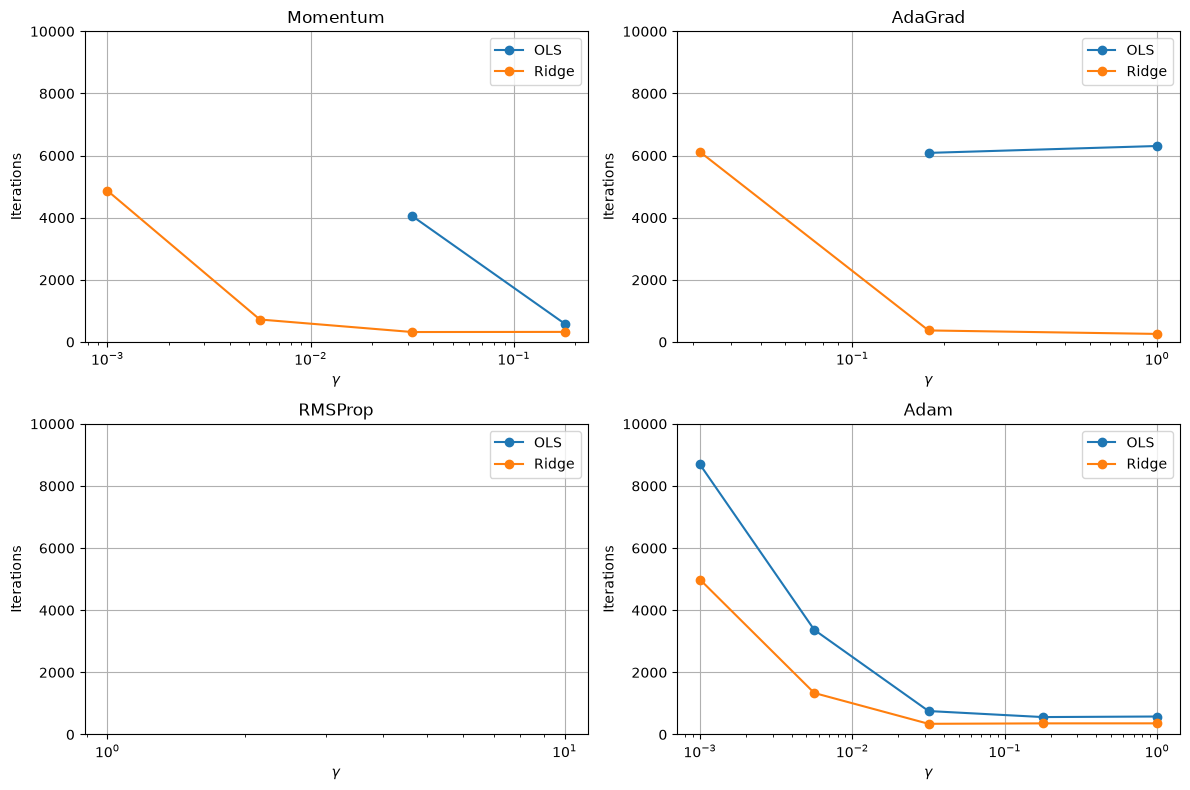

In [93]:
#f
#De
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

n=100
rng = np.random.default_rng(2026)
x = np.sort(rng.uniform(-1, 1, n))
y = runge(x) + rng.normal(0, sigma, n)

X = design_matrix(x, degree)

X_mean = X - np.mean(X, axis=0, keepdims=True)
X_std = np.empty((n, degree+1))
X_std[:,1:] = X_mean[:,1:] / np.sqrt(np.var(X_mean[:,1:], axis=0, keepdims=True))
X_std[:,0] = np.ones(n)

Xtrain, Xtest, Ytrain, Ytest = train_test_split(
    X_std, y_std, test_size=0.2, random_state=2026
)

X_norm5 = Xtrain

n_train = len(X_norm5[:,0])
n_features5 = X_norm5.shape[1]

Hessian = (2/n_train) * X_norm5.T @ X_norm5
eig = np.linalg.eigvalsh(Hessian)
gamma_opt = 2 / (eig[0] + eig[-1])

# Parameters
num_iters = 100000
tol = 1e-8
lam = np.exp(-2)


#------------!!!!The rest of the code in the cell is created by ChatGPT:!!!!!-----------------
# Five gamma values between 0.001 and 1
gammas = np.logspace(-3, 0, 5)

# Other optimizer parameters
beta = 0.9
rho = 0.1
eps = 0.0001
beta1 = 0.9
beta2 = 0.999


# ---------------------------------------------------------
# OLS
# ---------------------------------------------------------

OLS_momentum_iters = []
OLS_AdaGrad_iters = []
OLS_RMSProp_iters = []
OLS_Adam_iters = []

for gamma in gammas:

    # Momentum
    v = np.zeros(n_features5)
    theta = np.zeros(n_features5)

    for t in range(1, num_iters + 1):
        grad = (2/n_train) * X_norm5.T @ (X_norm5 @ theta - Ytrain)

        v = beta*v + gamma*grad
        theta = theta - v

        if np.linalg.norm(grad) < tol:
            break

    OLS_momentum_iters.append(t)


    # AdaGrad
    r = np.zeros(n_features5)
    theta = np.zeros(n_features5)

    for t in range(1, num_iters + 1):
        grad = (2/n_train) * X_norm5.T @ (X_norm5 @ theta - Ytrain)

        r = r + grad**2
        theta = theta - (gamma*grad)/np.sqrt(eps+r)

        if np.linalg.norm(grad) < tol:
            break

    OLS_AdaGrad_iters.append(t)


    # RMSProp
    r = np.zeros(n_features5)
    theta = np.zeros(n_features5)

    for t in range(1, num_iters + 1):
        grad = (2/n_train) * X_norm5.T @ (X_norm5 @ theta - Ytrain)

        r = rho*r + (1-rho)*grad**2
        theta = theta - gamma*grad/(np.sqrt(r)+eps)

        if np.linalg.norm(grad) < tol:
            break

    OLS_RMSProp_iters.append(t)


    # Adam
    m = np.zeros(n_features5)
    r = np.zeros(n_features5)
    theta = np.zeros(n_features5)

    for t in range(1, num_iters + 1):
        grad = (2/n_train) * X_norm5.T @ (X_norm5 @ theta - Ytrain)

        m = beta1*m + (1-beta1)*grad
        r = beta2*r + (1-beta2)*grad**2

        m_hat = m / (1-beta1**t)
        r_hat = r / (1-beta2**t)

        theta = theta - gamma*m_hat/(np.sqrt(r_hat)+eps)

        if np.linalg.norm(grad) < tol:
            break

    OLS_Adam_iters.append(t)


# ---------------------------------------------------------
# Ridge
# ---------------------------------------------------------

Ridge_momentum_iters = []
Ridge_AdaGrad_iters = []
Ridge_RMSProp_iters = []
Ridge_Adam_iters = []

for gamma in gammas:

    # Momentum
    v = np.zeros(n_features5)
    theta = np.zeros(n_features5)

    for t in range(1, num_iters + 1):
        grad = (
            (2/n_train) * X_norm5.T @ (X_norm5 @ theta - Ytrain)
            + 2*lam*theta
        )

        v = beta*v + gamma*grad
        theta = theta - v

        if np.linalg.norm(grad) < tol:
            break

    Ridge_momentum_iters.append(t)


    # AdaGrad
    r = np.zeros(n_features5)
    theta = np.zeros(n_features5)

    for t in range(1, num_iters + 1):
        grad = (
            (2/n_train) * X_norm5.T @ (X_norm5 @ theta - Ytrain)
            + 2*lam*theta
        )

        r = r + grad**2
        theta = theta - (gamma*grad)/np.sqrt(eps+r)

        if np.linalg.norm(grad) < tol:
            break

    Ridge_AdaGrad_iters.append(t)


    # RMSProp
    r = np.zeros(n_features5)
    theta = np.zeros(n_features5)

    for t in range(1, num_iters + 1):
        grad = (
            (2/n_train) * X_norm5.T @ (X_norm5 @ theta - Ytrain)
            + 2*lam*theta
        )

        r = rho*r + (1-rho)*grad**2
        theta = theta - gamma*grad/(np.sqrt(r)+eps)

        if np.linalg.norm(grad) < tol:
            break

    Ridge_RMSProp_iters.append(t)


    # Adam
    m = np.zeros(n_features5)
    r = np.zeros(n_features5)
    theta = np.zeros(n_features5)

    for t in range(1, num_iters + 1):
        grad = (
            (2/n_train) * X_norm5.T @ (X_norm5 @ theta - Ytrain)
            + 2*lam*theta
        )

        m = beta1*m + (1-beta1)*grad
        r = beta2*r + (1-beta2)*grad**2

        m_hat = m / (1-beta1**t)
        r_hat = r / (1-beta2**t)

        theta = theta - gamma*m_hat/(np.sqrt(r_hat)+eps)

        if np.linalg.norm(grad) < tol:
            break

    Ridge_Adam_iters.append(t)


# ---------------------------------------------------------
# Convert iteration results to NumPy arrays
# ---------------------------------------------------------

OLS_momentum_iters = np.array(OLS_momentum_iters, dtype=float)
OLS_AdaGrad_iters = np.array(OLS_AdaGrad_iters, dtype=float)
OLS_RMSProp_iters = np.array(OLS_RMSProp_iters, dtype=float)
OLS_Adam_iters = np.array(OLS_Adam_iters, dtype=float)

Ridge_momentum_iters = np.array(Ridge_momentum_iters, dtype=float)
Ridge_AdaGrad_iters = np.array(Ridge_AdaGrad_iters, dtype=float)
Ridge_RMSProp_iters = np.array(Ridge_RMSProp_iters, dtype=float)
Ridge_Adam_iters = np.array(Ridge_Adam_iters, dtype=float)


# ---------------------------------------------------------
# Set iteration counts above 10000 to NaN
# ---------------------------------------------------------

max_iters_plot = 10000

OLS_momentum_iters[OLS_momentum_iters > max_iters_plot] = np.nan
OLS_AdaGrad_iters[OLS_AdaGrad_iters > max_iters_plot] = np.nan
OLS_RMSProp_iters[OLS_RMSProp_iters > max_iters_plot] = np.nan
OLS_Adam_iters[OLS_Adam_iters > max_iters_plot] = np.nan

Ridge_momentum_iters[Ridge_momentum_iters > max_iters_plot] = np.nan
Ridge_AdaGrad_iters[Ridge_AdaGrad_iters > max_iters_plot] = np.nan
Ridge_RMSProp_iters[Ridge_RMSProp_iters > max_iters_plot] = np.nan
Ridge_Adam_iters[Ridge_Adam_iters > max_iters_plot] = np.nan


# ---------------------------------------------------------
# Create a 2x2 table of plots
# ---------------------------------------------------------

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Make the axes easier to access
ax1, ax2, ax3, ax4 = axes.flatten()


# ---------------------------------------------------------
# Momentum
# ---------------------------------------------------------

ax1.plot(gammas, OLS_momentum_iters, marker='o', label='OLS')
ax1.plot(gammas, Ridge_momentum_iters, marker='o', label='Ridge')

ax1.set_xscale('log')
ax1.set_xlabel(r'$\gamma$')
ax1.set_ylabel('Iterations')
ax1.set_title('Momentum')
ax1.set_ylim(0, max_iters_plot)
ax1.grid()
ax1.legend()


# ---------------------------------------------------------
# AdaGrad
# ---------------------------------------------------------

ax2.plot(gammas, OLS_AdaGrad_iters, marker='o', label='OLS')
ax2.plot(gammas, Ridge_AdaGrad_iters, marker='o', label='Ridge')

ax2.set_xscale('log')
ax2.set_xlabel(r'$\gamma$')
ax2.set_ylabel('Iterations')
ax2.set_title('AdaGrad')
ax2.set_ylim(0, max_iters_plot)
ax2.grid()
ax2.legend()


# ---------------------------------------------------------
# RMSProp
# ---------------------------------------------------------

ax3.plot(gammas, OLS_RMSProp_iters, marker='o', label='OLS')
ax3.plot(gammas, Ridge_RMSProp_iters, marker='o', label='Ridge')

ax3.set_xscale('log')
ax3.set_xlabel(r'$\gamma$')
ax3.set_ylabel('Iterations')
ax3.set_title('RMSProp')
ax3.set_ylim(0, max_iters_plot)
ax3.grid()
ax3.legend()


# ---------------------------------------------------------
# Adam
# ---------------------------------------------------------

ax4.plot(gammas, OLS_Adam_iters, marker='o', label='OLS')
ax4.plot(gammas, Ridge_Adam_iters, marker='o', label='Ridge')

ax4.set_xscale('log')
ax4.set_xlabel(r'$\gamma$')
ax4.set_ylabel('Iterations')
ax4.set_title('Adam')
ax4.set_ylim(0, max_iters_plot)
ax4.grid()
ax4.legend()


# ---------------------------------------------------------
# Improve the spacing between plots
# ---------------------------------------------------------

plt.tight_layout()
plt.show()

In [94]:
#Dette er modifisert fra koden fra ukesoppgavene uke 38

import numpy as np
import matplotlib.pyplot as plt

def exercise_data(n=100, degree=2, sigma=0.5, seed=2026):
    """Standardised polynomial design matrix (no intercept column) and centred targets."""
    rng = np.random.default_rng(seed)
    x = np.sort(rng.uniform(-1, 1, n))
    y = runge(x) + rng.normal(0, sigma, n)
    X = np.column_stack([x**k for k in range(1, degree + 1)])
    X_norm = (X - X.mean(axis=0)) / X.std(axis=0)
    return X_norm, y - y.mean()

def closed_form(X, y, lam=0.0):
    """(X^T X + n lambda I)^-1 X^T y, the 1/n convention of Eq. (3.95)."""
    n, p = X.shape
    return np.linalg.solve(X.T @ X + n * lam * np.eye(p), X.T @ y)

def cost(theta, X, y, lam=0.0):
    """Eqs. (4.12) and (4.16)."""
    return np.sum((X @ theta - y) ** 2) / len(y) + lam * theta @ theta

def gradient(theta, X, y, lam=0.0):
    """Eqs. (4.13) and (4.17): your analytical gradient from last week (or jax.grad of cost)."""
    n = len(y)
    return (2.0 / n) * X.T @ (X @ theta - y) + 2.0 * lam * theta

def hessian_eigs(X, lam=0.0):
    n = len(X)
    return np.linalg.eigvalsh((2.0 / n) * X.T @ X + 2.0 * lam * np.eye(X.shape[1]))

X2, y2 = exercise_data(degree=2)
X5, y5 = exercise_data(degree=5)
for X in (X2, X5):
    eigs = hessian_eigs(X)
    print(f"degree {X.shape[1]}: kappa = {eigs.max() / eigs.min():.1f}, 2/lambda_max = {2 / eigs.max():.3f}")

#---------Skrevet av ChatGPT--------------------------
def optimiser_step(method, theta, g, state, t, gamma, beta=0.9, rho=0.99,
                   beta1=0.9, beta2=0.999, eps=1e-8):
    """LLM assisted"""

    if method == "plain":
        return theta - gamma * g, state

    if method == "momentum":
        v = state.get("v", np.zeros_like(theta))
        v = beta * v + (1 - beta) * g
        state["v"] = v

        return theta - gamma*v, state

    if method == "adagrad":
        r = state.get("r", np.zeros_like(theta))
        r = r + g**2
        state["r"] = r

        return theta - gamma * g / np.sqrt(eps + r), state

    if method == "rmsprop":
        r = state.get("r", np.zeros_like(theta))
        r = rho * r + (1 - rho) * g**2
        state["r"] = r

        return theta - gamma * g / np.sqrt(r + eps), state

    if method == "adam":
        m = state.get("m", np.zeros_like(theta))
        r = state.get("r", np.zeros_like(theta))

        m = beta1 * m + (1 - beta1) * g
        r = beta2 * r + (1 - beta2) * g**2

        state["m"] = m
        state["r"] = r

        # Bias correction
        m_hat = m / (1 - beta1**t)
        r_hat = r / (1 - beta2**t)

        return theta - gamma * m_hat / (np.sqrt(r_hat) + eps), state

    raise ValueError(f"unknown method {method}")
#------------------------------------------


def optimise(grad, theta0, method, gamma, num_iters=1000, tol=1e-8, **kw):
    """Full-gradient loop; returns all iterates and the number of steps taken."""
    theta, state = np.array(theta0, dtype=float), {}
    history = [theta.copy()]
    for t in range(1, num_iters + 1):
        g = grad(theta)
        theta, state = optimiser_step(method, theta, g, state, t, gamma, **kw)
        history.append(theta.copy())
        if np.linalg.norm(g) < tol:
            break
    return np.array(history), t

theta = np.zeros(2)
lbd = 0.01
gamma = 0.5
def grad_2(theta):
    return gradient(theta, X2, y2, lbd)

a,b = optimise(grad_2, theta, "momentum", gamma)
print(a[-1])
print(closed_form(X2, y2, lbd))



degree 2: kappa = 1.3, 2/lambda_max = 0.894
degree 5: kappa = 520.3, 2/lambda_max = 0.354
[ 0.04750049 -0.23421919]
[ 0.04750049 -0.23421919]


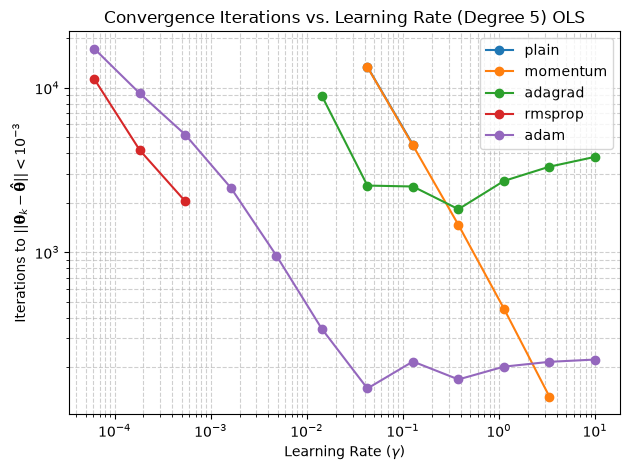

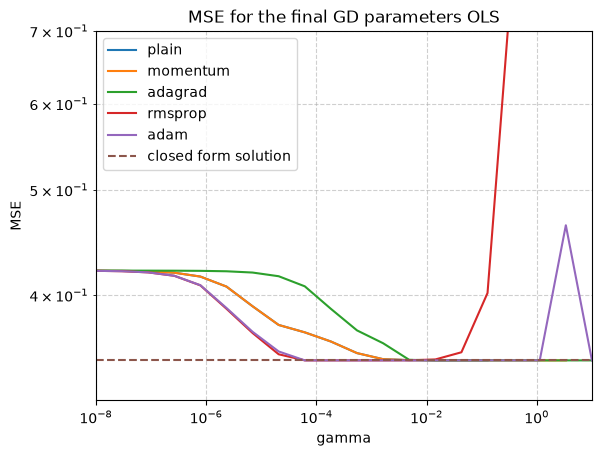

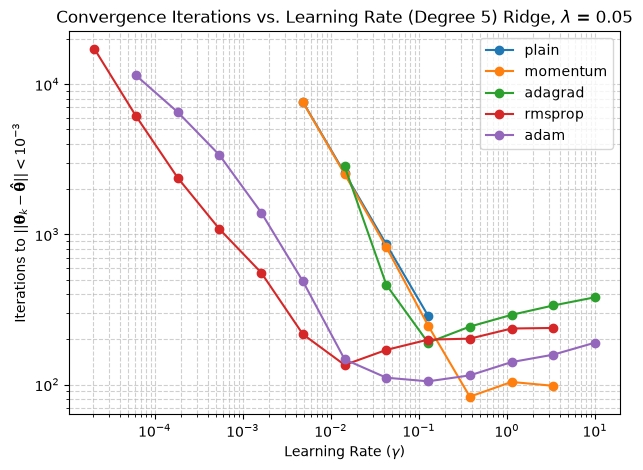

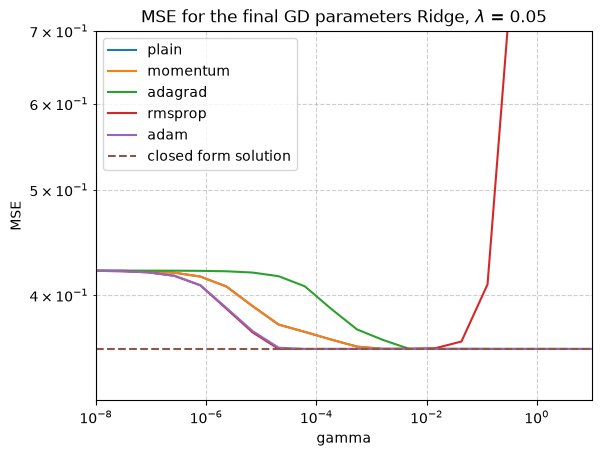

In [95]:
num = 20
gammas = np.logspace(-8,1,num)


#Resten skrevet av gemini med litt input fra meg:
lambdas = [0, 0.05]
types = ["OLS", r"Ridge, $\lambda$ = "+str(lambdas[1])]

max_iters = 20000
target_tol = 1e-3
methods = ["plain", "momentum", "adagrad", "rmsprop", "adam"]
mse = np.zeros((len(methods), num))

#iterating through penalty terms lambda
for lbd, regression_type in zip(lambdas, types):
    grad_5_fn = lambda theta: gradient(theta, X5, y5, lam=lbd)
    theta_exact_5 = closed_form(X5, y5, lbd)

    #Iterationg through methods
    for j, method in enumerate(methods):
        iterations_to_target = np.full(num, np.nan)

        #iterating through the learning rates
        for i, gamma in enumerate(gammas):
            theta0 = np.zeros(X5.shape[1])
            
            # Run full optimization budget without stopping on gradient tolerance
            history, _ = optimise(grad_5_fn, theta0, method, gamma, num_iters=max_iters, tol=0)
            
            # Compute exact error distance ||theta_k - theta_hat|| for each iteration step
            distances = np.linalg.norm(history - theta_exact_5, axis=1)
            
            # Find first iteration step reaching the threshold
            converged_steps = np.where(distances < target_tol)[0]
            
            if len(converged_steps) > 0:
                iterations_to_target[i] = converged_steps[0]
            else:
                # Set to max_iters (or np.nan) to indicate non-convergence
                iterations_to_target[i] = np.nan
            mse[j][i] = np.mean((y2 - X5@history[-1])**2)

        plt.loglog(gammas, iterations_to_target, marker="o", label=method)

    #Plot the iterations to convergence:
    plt.xlabel(r"Learning Rate ($\gamma$)")
    plt.ylabel(r"Iterations to $||\mathbf{\theta}_k - \mathbf{\hat{\theta}}|| < 10^{-3}$")
    plt.title("Convergence Iterations vs. Learning Rate (Degree 5) "+regression_type)
    plt.grid(True, which="both", linestyle="--", alpha=0.6)
    plt.legend()
    plt.tight_layout()
    plt.show()

    #Plot the final MSE of the fitted functions
    closed_form_mse = np.mean((y2 - X5@theta_exact_5)**2)
    for i, method in enumerate(methods):
        plt.loglog(gammas, mse[i,:])
    plt.loglog(gammas, closed_form_mse*np.ones(len(gammas)), linestyle = "--")
    plt.grid(True, which="both", linestyle="--", alpha=0.6)
    plt.title("MSE for the final GD parameters "+regression_type)
    plt.legend(methods+["closed form solution"])
    plt.xlabel("gamma")
    plt.ylabel("MSE")
    plt.ylim(0.32, 0.7)
    plt.xlim(10**(-8), 10)
    plt.show()

In [96]:
#Printing the condition number for the Hessian matrix
for lam, method in zip([0, 0.05], ["OLS", "Ridge lambda = 0.05"]):
    Hessian = (2/n)*X5.T@X5+2*lam*np.identity(5)
    eig = np.linalg.eigvalsh(Hessian)
    condition_number = eig[-1]/eig[0]
    gamma_opt = 2/(eig[0]+eig[-1])

    print("condition number ", method, ": ", condition_number)
    print("optimal gamma plain GD", method, ": ", gamma_opt)
    print("")


condition number  OLS :  520.3442674565816
optimal gamma plain GD OLS :  0.3531322587224054

condition number  Ridge lambda = 0.05 :  51.89029061782014
optimal gamma plain GD Ridge lambda = 0.05 :  0.3410873636091098



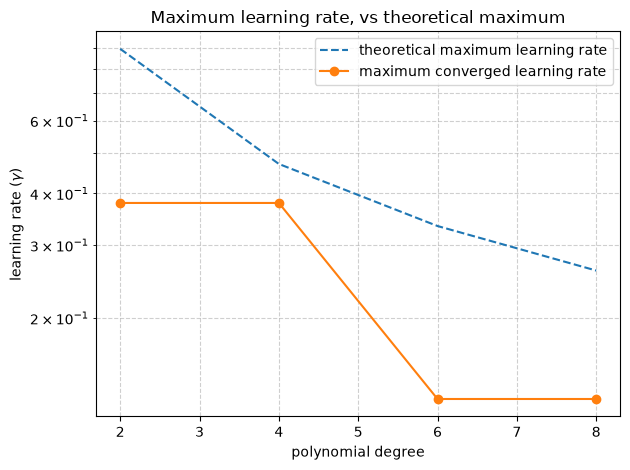

In [97]:
#This code verifies the analytical expression for the maximum possible learning rate.
#The maximum learning rate that converged will always be less than the theoretical maximum 

#Defining the degreees of the polynomial.
degrees = [i for i in range(2,10,2)]

#The data for each degree of polynomial
data_list = [exercise_data(degree = i) for i in degrees]
length_data = len(data_list)


num = 20 #number of gammas used per polynomial degree
gammas = np.logspace(-8,1,num)


max_iters = 20000
target_tol = 1e-3
methods = ["plain", "momentum", "adagrad", "rmsprop", "adam"]
mse = np.zeros((len(methods), num))
method = "plain"

#This is the maximum learning rate that converged for a given polynomial degree
max_converged_learning_rate = np.zeros(length_data)

for j, data in enumerate(data_list):
    grad_5_fn = lambda theta: gradient(theta, data[0], data[1], lam=lbd)
    theta_exact_5 = closed_form(data[0], data[1], lbd)

    iterations_to_target = np.full(num, np.nan)
    
    for i, gamma in enumerate(gammas):
        theta0 = np.zeros(data[0].shape[1])
        
        # Run full optimization budget without stopping on gradient tolerance
        history, _ = optimise(grad_5_fn, theta0, method, gamma, num_iters=max_iters, tol=0)
        
        # Compute exact error distance ||theta_k - theta_hat|| for each iteration step
        distances = np.linalg.norm(history - theta_exact_5, axis=1)
        
        # Find first iteration step reaching the threshold
        converged_steps = np.where(distances < target_tol)[0]
        
        if len(converged_steps) > 0:
            iterations_to_target[i] = converged_steps[0]
        else:
            # Set to max_iters (or np.nan) to indicate non-convergence
            iterations_to_target[i] = np.nan
        mse[j][i] = np.mean((data[1] - data[0]@history[-1])**2)
    #-----------ChatGPT la til denne koden-------
    converged = np.where(np.isfinite(iterations_to_target))[0]

    if len(converged) > 0:
        max_converged_learning_rate[j] = gammas[converged[-1]]
    else:
        max_converged_learning_rate[j] = np.nan
    #------------------------------------------

#Finding the maximum possible learning rate
eigs = [max(np.linalg.eigvalsh((2/n)*data[0].T@data[0])) for data in data_list]
max_gamma = [2/eig for eig in eigs]

#plotting the data:
plt.plot(degrees, max_gamma, linestyle = "--", label = "theoretical maximum learning rate")
plt.plot(degrees, max_converged_learning_rate, marker="o", label="maximum converged learning rate")
plt.yscale("log")

plt.xlabel(r"polynomial degree")
plt.ylabel(r"learning rate $(\gamma)$")
plt.title("Maximum learning rate, vs theoretical maximum")
plt.grid(True, which="both", linestyle="--", alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()


The plot shows the number of iterations for the methods to converge for different

In [98]:
print("jax.grad(jnp.abs)(0.0) =", jax.grad(jnp.abs)(0.0))
print("jax.grad(jnp.abs)(-0.3) =", jax.grad(jnp.abs)(-0.3), " jax.grad(jnp.abs)(0.3) =", jax.grad(jnp.abs)(0.3))

jax.grad(jnp.abs)(0.0) = 1.0
jax.grad(jnp.abs)(-0.3) = -1.0  jax.grad(jnp.abs)(0.3) = 1.0


This does not make sense for the derivative of |0.0| the program says 1.0, but the derivative is not defined here. if i look at the definition going in different directions: $\lim_{\epsilon \rightarrow{} 0^+}\frac{|\epsilon|-|0|}{\epsilon-0} = 1$ and $\lim_{\epsilon \rightarrow{} 0^-}\frac{|\epsilon|-|0|}{\epsilon-0} = -1$ so the gradient is not defined here. at $\theta_i=0$ the penalty $\lambda |\theta_i|$ has no preference for whether theta increases or decreases. Therefore it is possible to say that the gradient here should be zero even though that is not mathematically correct. A more advanced method would be to modify the optimizer function so that it looks at the step it is about to take with lasso, and if , and if the step crosses a $\theta_i = 0$ the optimizer automatically sets that $\theta_i$ to zero, then it monitors the unpenalized gradient in the $\theta_i$ dimension and only allows the $\theta_i$ to become nonzero if the absolute value of the gradient in that dimension is higher than the penalty gradient.

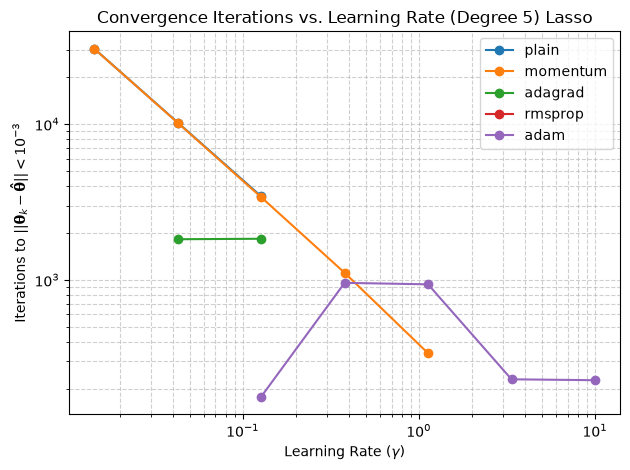

In [99]:
#g Lasso

import sklearn

#Defining the Lasso gradient
def gradient_lasso(theta, X, y, lam=0.0):
    """simple lasso gradient"""
    n = len(y)
    return (2.0 / n) * X.T @ (X @ theta - y) + lam * np.sign(theta)

#Defining the parameters
lbd = 0.001
num = 20
gammas = np.logspace(-8,1,num)

#Finding the coefficients with sklearn
lasso_model = sklearn.linear_model.Lasso(alpha = lbd/2)
theta_exact_5 = lasso_model.fit(X5,y5).coef_

#Resten skrevet av Gemini, jeg modifiserte det for Lasso regression i stedet for OLS.
grad_5_fn = lambda theta: gradient_lasso(theta, X5, y5, lam = lbd)
max_iters = 50000
target_tol = 0.001

methods = ["plain", "momentum", "adagrad", "rmsprop", "adam"]
for method in methods:
    iterations_to_target = np.zeros(num)
    
    for i, gamma in enumerate(gammas):
        theta0 = np.zeros(X5.shape[1])
        
        # Run full optimization budget without stopping on gradient tolerance
        with np.errstate(over='ignore', invalid='ignore'):
            history, _ = optimise(grad_5_fn, theta0, method, gamma, num_iters=max_iters, tol=0)
        
        # Compute exact error distance ||theta_k - theta_hat|| for each iteration step
        distances = np.linalg.norm(history - theta_exact_5, axis=1)
        
        # Find first iteration step reaching the threshold
        converged_steps = np.where(distances < target_tol)[0]
        
        if len(converged_steps) > 0:
            iterations_to_target[i] = converged_steps[0]
        else:
            # Set to max_iters (or np.nan) to indicate non-convergence
            iterations_to_target[i] = np.nan

    plt.loglog(gammas, iterations_to_target, marker="o", label=method)

#Plot the results
plt.xlabel(r"Learning Rate ($\gamma$)")
plt.ylabel(r"Iterations to $||\mathbf{\theta}_k - \mathbf{\hat{\theta}}|| < 10^{-3}$")
plt.title("Convergence Iterations vs. Learning Rate (Degree 5) Lasso")
plt.grid(True, which="both", linestyle="--", alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

In [100]:
#h
#denne koden var kopiert fra oppgavesiden fra ukesoppgave 38
def make_batches(n, batch_size, rng):
    """Shuffle the indices and split them into minibatches."""
    idx = rng.permutation(n)
    return [idx[i:i + batch_size] for i in range(0, n, batch_size)]

def step_length(t, t0, t1):
    """The schedule of Eq. (4.40)."""
    return t0/(t+t1)

def sgd(X, y, method="plain", n_epochs=50, batch_size=5, gamma=0.1, schedule=None, lam=0.0, seed=2026, **kw):
    """Minibatch SGD, Eq. (4.34), with any optimiser. schedule=(t0, t1) replaces gamma by Eq. (4.40).
    Returns the iterate after every epoch."""
    rng = np.random.default_rng(seed)
    n, p = X.shape
    theta, state, t = np.zeros(p), {}, 0
    history = [theta.copy()]
    for epoch in range(n_epochs):
        for batch in make_batches(n, batch_size, rng):
            t += 1
            g = gradient(theta, X[batch],y[batch],lam) # the gradient of the cost on this minibatch
            gamma_t = step_length(t, schedule[0], schedule[1]) if schedule is not None else gamma               # constant, or the schedule
            theta, state = optimiser_step(method, theta, g, state, t, gamma_t, **kw)
            history.append(theta.copy())
    return np.array(history)

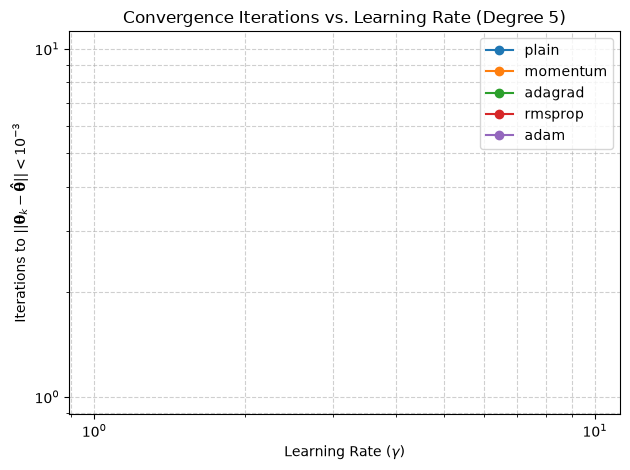

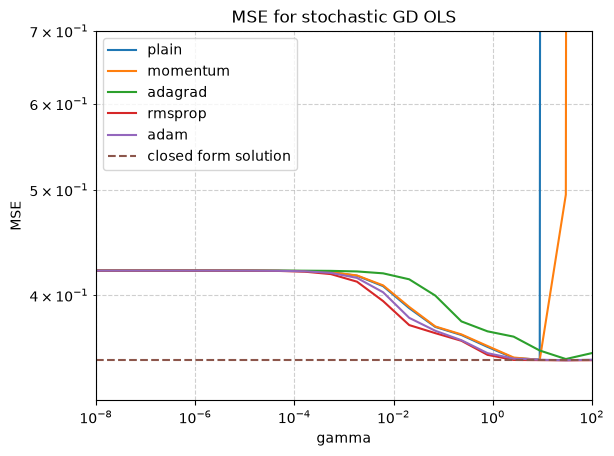

In [101]:
#h
X5, y5 = exercise_data(degree=5, n = 100)

num = 20
gammas = np.logspace(-8,2,num)
n_epochs = 1000
batch_size = 5


target_tol = 0.001
methods = ["plain", "momentum", "adagrad", "rmsprop", "adam"]

mse = np.zeros((len(methods), num))


grad_5_fn = lambda theta: gradient(theta, X5, y5, lam=0.0)
theta_exact_5 = closed_form(X5, y5, 0.0)
for j, method in enumerate (methods):
    iterations_to_target = np.zeros(num)

    #Iterate over different learning rates
    for i, gamma in enumerate(gammas):
        theta0 = np.zeros(X5.shape[1])
        
        # Run full optimization budget without stopping on gradient 
        gamma_schedule = (gamma, 10)
        history = sgd(X5, y5, method, n_epochs = n_epochs, batch_size = batch_size, schedule=gamma_schedule)
        
        # Compute exact error distance ||theta_k - theta_hat|| for each iteration step
        distances = np.linalg.norm(history - theta_exact_5, axis=1)
        
        # Find first iteration step reaching the threshold
        converged_steps = np.where(distances < target_tol)[0]
        
        if len(converged_steps) > 0:
            iterations_to_target[i] = converged_steps[0]
        else:
            # Set to max_iters (or np.nan) to indicate non-convergence
            iterations_to_target[i] = np.nan

        mse[j][i] = np.mean((y2 - X5@history[-1])**2)

    plt.loglog(gammas, iterations_to_target, marker="o", label=method)

closed_form_mse = np.mean((y2-X5@theta_exact_5)**2)

#Plot the iterations to convergance
plt.xlabel(r"Learning Rate ($\gamma$)")
plt.ylabel(r"Iterations to $||\mathbf{\theta}_k - \mathbf{\hat{\theta}}|| < 10^{-3}$")
plt.title("Convergence Iterations vs. Learning Rate (Degree 5)")
plt.grid(True, which="both", linestyle="--", alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

#Plot the MSE as a function of learning rate
for i, method in enumerate(methods):
    plt.loglog(gammas, mse[i,:])
plt.loglog(gammas, closed_form_mse*np.ones(len(gammas)), linestyle = "--")
plt.grid(True, which="both", linestyle="--", alpha=0.6)
plt.title("MSE for stochastic GD OLS")
plt.legend(methods+["closed form solution"])
plt.xlabel("gamma")
plt.ylabel("MSE")
plt.ylim(0.32, 0.7)
plt.xlim(10**(-8), 100)
plt.show()

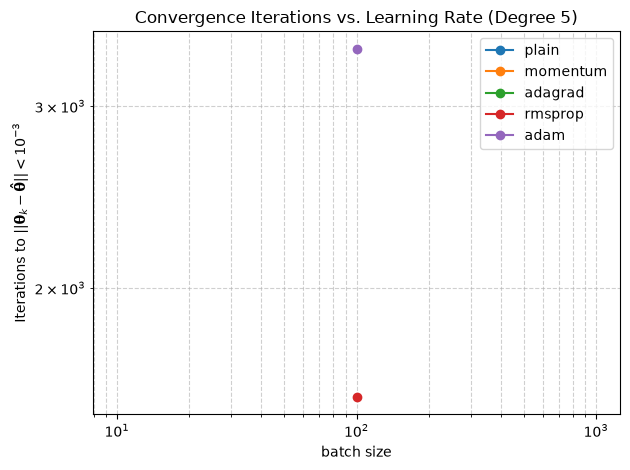

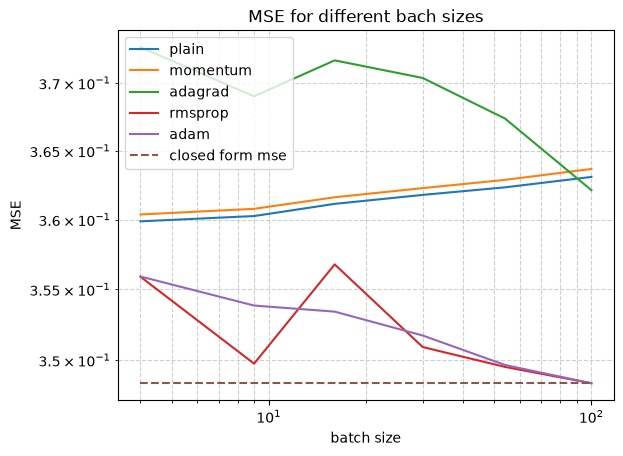

In [102]:
#h
X5, y5 = exercise_data(degree=5, n = 100)

#Set the parameters
num = 6
n_epochs = 10000
batch_sizes = np.int32(np.exp(np.linspace(np.log(5), np.log(n), num)))
gamma = 0.5


target_tol = 0.001
methods = ["plain", "momentum", "adagrad", "rmsprop", "adam"]

mse = np.zeros((len(methods), num))


grad_5_fn = lambda theta: gradient(theta, X5, y5, lam=0.0)
theta_exact_5 = closed_form(X5, y5, 0.0)
for j, method in enumerate (methods):
    iterations_to_target = np.zeros(num)

    #iterate over different batch sizes:
    for i, batch_size in enumerate(batch_sizes):
        theta0 = np.zeros(X5.shape[1])
        
        # Run full optimization budget without stopping on gradient 
        gamma_schedule = (gamma, 10)
        history = sgd(X5, y5, method, n_epochs = n_epochs, batch_size = batch_size, schedule=gamma_schedule)
        
        # Compute exact error distance ||theta_k - theta_hat|| for each iteration step
        distances = np.linalg.norm(history - theta_exact_5, axis=1)
        
        # Find first iteration step reaching the threshold
        converged_steps = np.where(distances < target_tol)[0]
        
        if len(converged_steps) > 0:
            iterations_to_target[i] = converged_steps[0]
        else:
            # Set to max_iters (or np.nan) to indicate non-convergence
            iterations_to_target[i] = np.nan

        mse[j][i] = np.mean((y5 - X5@history[-1])**2)
        if mse[j][i] >1:
            mse[j][i] = np.nan

    plt.loglog(batch_sizes, iterations_to_target, marker="o", label=method)

closed_form_mse = np.mean((y2-X5@theta_exact_5)**2)

#Plot the methods that converged for a given batch size
plt.xlabel(r"batch size")
plt.ylabel(r"Iterations to $||\mathbf{\theta}_k - \mathbf{\hat{\theta}}|| < 10^{-3}$")
plt.title("Convergence Iterations vs. Learning Rate (Degree 5)")
plt.grid(True, which="both", linestyle="--", alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

#plot the MSE for the fitted function for given batch size
for i, method in enumerate(methods):
    plt.loglog(batch_sizes, mse[i,:])
plt.loglog(batch_sizes, closed_form_mse*np.ones(len(batch_sizes)), linestyle = "--")
plt.grid(True, which="both", linestyle="--", alpha=0.6)
plt.title("MSE for different bach sizes")
plt.legend(methods+["closed form mse"])
plt.xlabel("batch size")
plt.ylabel("MSE")
plt.show()
    

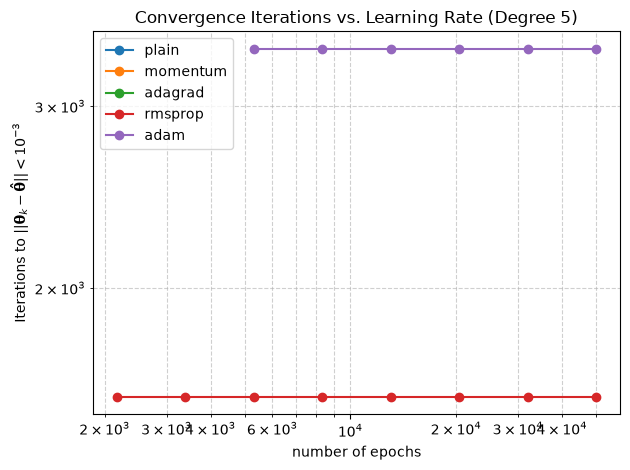

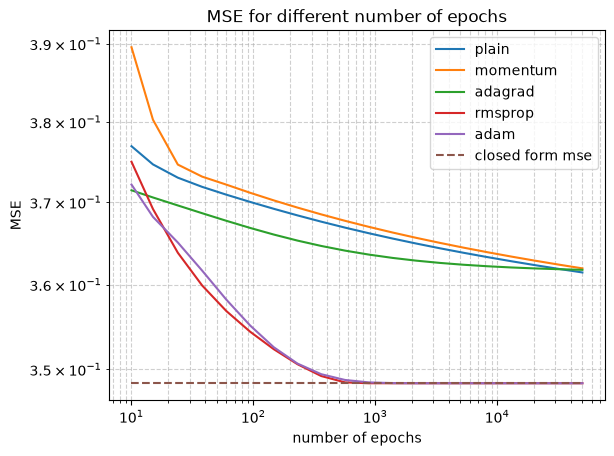

In [103]:
#h
X5, y5 = exercise_data(degree=5, n = 100)

num = 20
max_epochs = 50000
min_epochs = 10
n_epochs_list = np.int32(np.exp(np.linspace(np.log(min_epochs), np.log(max_epochs), num)))
gamma = 0.5
batch_sizes = 5


methods = ["plain", "momentum", "adagrad", "rmsprop", "adam"]

mse = np.zeros((len(methods), num))


grad_5_fn = lambda theta: gradient(theta, X5, y5, lam=0.0)
theta_exact_5 = closed_form(X5, y5, 0.0)
for j, method in enumerate (methods):
    iterations_to_target = np.zeros(num)

    #Iterate through number of epochs
    for i, n_epochs in enumerate(n_epochs_list):
        theta0 = np.zeros(X5.shape[1])
        
        # Run full optimization budget without stopping on gradient 
        gamma_schedule = (gamma, 10)
        history = sgd(X5, y5, method, n_epochs = n_epochs, batch_size = batch_size, schedule=gamma_schedule)
        
        # Compute exact error distance ||theta_k - theta_hat|| for each iteration step
        distances = np.linalg.norm(history - theta_exact_5, axis=1)
        
        # Find first iteration step reaching the threshold
        converged_steps = np.where(distances < target_tol)[0]
        
        if len(converged_steps) > 0:
            iterations_to_target[i] = converged_steps[0]
        else:
            # Set to max_iters (or np.nan) to indicate non-convergence
            iterations_to_target[i] = np.nan

        mse[j][i] = np.mean((y5 - X5@history[-1])**2)
        if mse[j][i] >1:
            mse[j][i] = np.nan

    plt.loglog(n_epochs_list, iterations_to_target, marker="o", label=method)

closed_form_mse = np.mean((y2-X5@theta_exact_5)**2)

#plot converged methods
plt.xlabel(r"number of epochs")
plt.ylabel(r"Iterations to $||\mathbf{\theta}_k - \mathbf{\hat{\theta}}|| < 10^{-3}$")
plt.title("Convergence Iterations vs. Learning Rate (Degree 5)")
plt.grid(True, which="both", linestyle="--", alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

#Plot MSE of fitted functions
for i, method in enumerate(methods):
    plt.loglog(n_epochs_list, mse[i,:])
plt.loglog(n_epochs_list, closed_form_mse*np.ones(len(n_epochs_list)), linestyle = "--")
plt.grid(True, which="both", linestyle="--", alpha=0.6)
plt.title("MSE for different number of epochs")
plt.legend(methods+["closed form mse"])
plt.xlabel("number of epochs")
plt.ylabel("MSE")
plt.show()
    

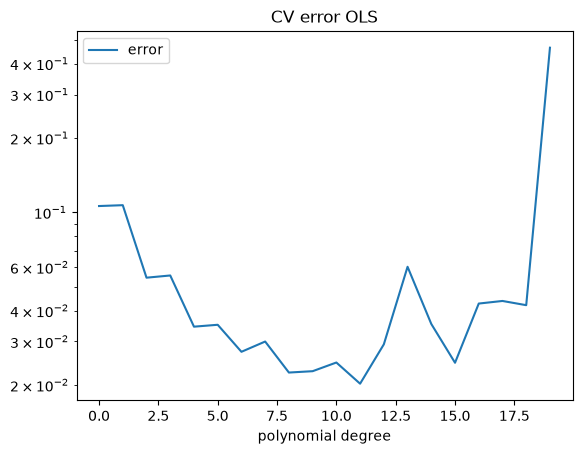

min error:  0.02023726542600979
degree with min error:  11


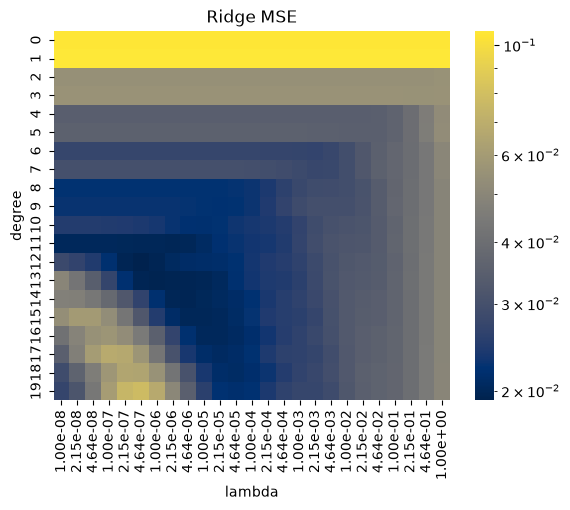

min error:  0.019114999841472493
degree with min error:  12
minimum lambda:  4.6415888336127725e-07


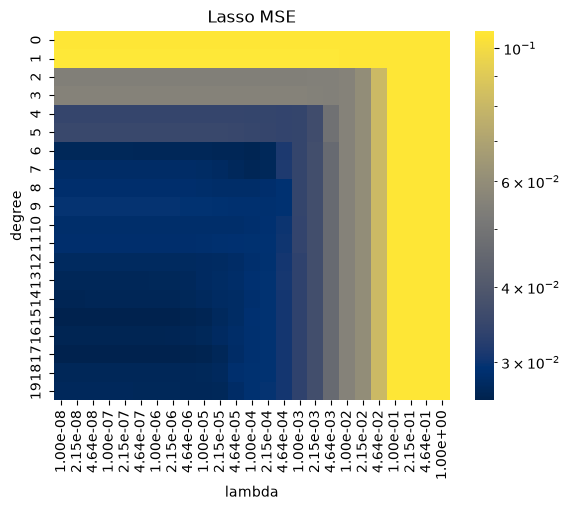

min error:  0.025909949163423995
degree with min error:  15
minimum lambda:  1e-08

The best model was Ridge regression with lambda =  4.6415888336127725e-07  and degree:  12


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('polynomialfeatures', ...), ('ridge', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,1
,"degree degree: int or tuple (min_degree, max_degree), default=2If a single int is given, it specifies the maximal degree of thepolynomial features. If a tuple `(min_degree, max_degree)` is passed,then `min_degree` is the minimum and `max_degree` is the maximumpolynomial degree of the generated features. Note that `min_degree=0`and `min_degree=1` are equivalent as outputting the degree zero term isdetermined by `include_bias`.",12
,"interaction_only interaction_only: bool, default=FalseIf `True`, only interaction features are produced: features that areproducts of at most `degree` *distinct* input features, i.e. terms withpower of 2 or higher of the same input feature are excluded:- included: `x[0]`, `x[1]`, `x[0] * x[1]`, etc.- excluded: `x[0] ** 2`, `x[0] ** 2 * x[1]`, etc.",False
,"include_bias include_bias: bool, default=TrueIf `True` (default), then include a bias column, the feature in whichall polynomial powers are zero (i.e. a column of ones - acts as anintercept term in a linear model).",True
,"order order: {'C', 'F'}, default='C'Order of output array in the dense case. `'F'` order is faster tocompute, but may slow down subsequent estimators... versionadded:: 0.21",'C'
Name,Type,Value


In [104]:
rng = np.random.default_rng(2026)
n = 100
sigma = 0.1
x = np.sort(rng.uniform(-1, 1, n))
y = runge(x) + rng.normal(0, sigma, n)

#i
from sklearn.model_selection import train_test_split, KFold, cross_val_score
import seaborn as sns
from matplotlib.colors import LogNorm
from sklearn.linear_model import Lasso
from sklearn.preprocessing import StandardScaler

np.random.seed(2026)

#Set parameters of the program:
maxdegree = 20
splits = 10
num = 25

#Create folds
kf = KFold(n_splits = splits, shuffle = True, random_state=2026)

#initialize OLS MSE
MSE = np.zeros(maxdegree)

#OLS:
for deg in range(maxdegree):
    mse = np.zeros(splits)

    model = make_pipeline(PolynomialFeatures(degree = deg), LinearRegression(fit_intercept= False))
    
    #Iterate over folds
    for i, (train_idx, test_idx) in enumerate(kf.split(x)):
        y_pred = model.fit(x.reshape(-1,1)[train_idx], y[train_idx]).predict(x.reshape(-1,1)[test_idx])
        y_test = y[test_idx]

        mse[i] = np.mean((y_pred-y_test)**2)

    #Find the mean MSE
    MSE[deg] = np.mean(mse)

#Plot the MSE
x_axis = np.arange(maxdegree)
plt.yscale("log")
plt.xlabel("polynomial degree")
plt.title("CV error OLS")
plt.plot(x_axis, MSE)
plt.legend(["error"])

plt.show()
min_error_OLS = np.min(MSE)
print("min error: ", min_error_OLS)
print("degree with min error: ",np.argmin(MSE))

lambdas = np.logspace(-8,0, num)

#Ridge:
MSE_Ridge = np.zeros((maxdegree, num))

#Iterate over both labda and polynomial degree
for a, lbd in enumerate(lambdas):
    for deg in range(maxdegree):
        mse = np.zeros(splits)

        model = make_pipeline(PolynomialFeatures(degree = deg), Ridge(alpha = lbd))
        #Iterate over folds
        for i, (train_idx, test_idx) in enumerate(kf.split(x)):
            y_pred = model.fit(x.reshape(-1,1)[train_idx], y[train_idx]).predict(x.reshape(-1,1)[test_idx])
            y_test = y[test_idx]

            mse[i] = np.mean((y_pred-y_test)**2)
        
        MSE_Ridge[deg, a] = np.mean(mse)
#Plot the MSE
sns.heatmap(MSE_Ridge, norm = LogNorm(), xticklabels = [f"{l:.2e}" for l in lambdas], cmap = "cividis")
plt.title("Ridge MSE")
plt.xlabel("lambda")
plt.ylabel("degree")

plt.show()
min_error_Ridge = np.min(MSE_Ridge)
print("min error: ",min_error_Ridge)
min_idx_ridge = np.argmin(MSE_Ridge)
min_degree_ridge = int(min_idx_ridge/num)
min_lambda_ridge = lambdas[min_idx_ridge%num]
print("degree with min error: ",min_degree_ridge)
print("minimum lambda: ", min_lambda_ridge)

#Lasso:
MSE_Lasso = np.zeros((maxdegree, num))
#iterate over lambda and the number of folds
for a, lbd in enumerate(lambdas):
    for deg in range(maxdegree):
        mse = np.zeros(splits)

        model = make_pipeline(PolynomialFeatures(degree = deg), Lasso(alpha = lbd))
        #Iterate through splits
        for i, (train_idx, test_idx) in enumerate(kf.split(x)):
            y_pred = model.fit(x.reshape(-1,1)[train_idx], y[train_idx]).predict(x.reshape(-1,1)[test_idx])
            y_test = y[test_idx]

            mse[i] = np.mean((y_pred-y_test)**2)

        MSE_Lasso[deg, a] = np.mean(mse)

#Plot the result
sns.heatmap(MSE_Lasso, norm = LogNorm(), xticklabels = [f"{l:.2e}" for l in lambdas], cmap = "cividis")
plt.title("Lasso MSE")
plt.xlabel("lambda")
plt.ylabel("degree")

plt.show()
min_error_Lasso = np.min(MSE_Lasso)
print("min error: ",min_error_Lasso)
min_idx_lasso = np.argmin(MSE_Lasso)
min_degree_lasso = int(min_idx_lasso/num)
min_lambda_lasso = lambdas[min_idx_lasso%num]
print("degree with min error: ",min_degree_lasso)
print("minimum lambda: ", min_lambda_lasso)

best_degree_OLS = np.argmin(MSE)

errors = np.array([min_error_OLS, min_error_Ridge, min_error_Lasso])
best_optimiser = np.argmin(errors)
print("")

#Find and print the best model:
if best_optimiser == 0:
    print("The best model was OLS with degree:", best_degree_OLS)
    best_model = make_pipeline(
        PolynomialFeatures(degree=best_degree_OLS),
        LinearRegression(fit_intercept=False)
    )

elif best_optimiser == 1:
    print("The best model was Ridge regression with lambda = ", min_lambda_ridge," and degree: ",min_degree_ridge)
    best_model = make_pipeline(
        PolynomialFeatures(degree=min_degree_ridge),
        Ridge(alpha=min_lambda_ridge)
    )

else:
    print("The best model was Lasso regression with lambda = ", min_lambda_lasso," and degree: ", min_degree_lasso)
    best_model = make_pipeline(
        PolynomialFeatures(degree=min_degree_lasso),
        Lasso(alpha=min_lambda_lasso)
    )

#This is the best model:
best_model.fit(x.reshape(-1,1), y)


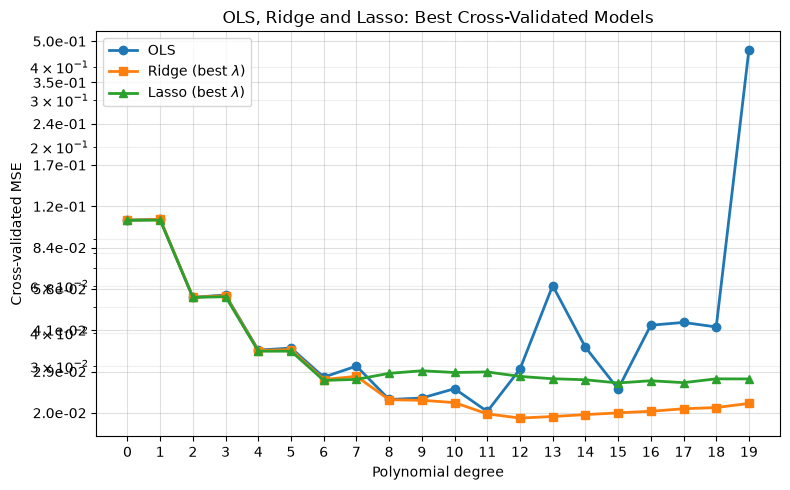

OLS
Best degree : 11
Best CV MSE : 0.02024

RIDGE
Best degree : 12
Best lambda : 4.6416e-07
Best CV MSE : 0.01911

LASSO
Best degree : 15
Best lambda : 1.0000e-08
Best CV MSE : 0.02591


In [105]:
from matplotlib.ticker import MultipleLocator
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# Part i: Final comparison figure and summary
# ==========================================

degrees = np.arange(maxdegree)

best_ridge_curve = np.min(MSE_Ridge, axis=1)
best_lasso_curve = np.min(MSE_Lasso, axis=1)

plt.figure(figsize=(8, 5))

plt.semilogy(
    degrees,
    MSE,
    marker="o",
    linewidth=2,
    label="OLS"
)

plt.semilogy(
    degrees,
    best_ridge_curve,
    marker="s",
    linewidth=2,
    label=r"Ridge (best $\lambda$)"
)

plt.semilogy(
    degrees,
    best_lasso_curve,
    marker="^",
    linewidth=2,
    label=r"Lasso (best $\lambda$)"
)

ax = plt.gca()

ax.xaxis.set_major_locator(MultipleLocator(1))

ticks = np.geomspace(0.02, 0.5, 10)

plt.yticks(
    ticks,
    [f"{t:.1e}" for t in ticks]
)

plt.xlabel("Polynomial degree")
plt.ylabel("Cross-validated MSE")
plt.title("OLS, Ridge and Lasso: Best Cross-Validated Models")

plt.grid(True, which="major", alpha=0.4)
plt.grid(True, which="minor", alpha=0.2)

plt.legend()
plt.tight_layout()
plt.show()

# ==========================================
# Best parameters
# ==========================================

best_degree_OLS = np.argmin(MSE)
best_error_OLS = np.min(MSE)

ridge_degree, ridge_lambda_idx = np.unravel_index(
    np.argmin(MSE_Ridge),
    MSE_Ridge.shape
)

lasso_degree, lasso_lambda_idx = np.unravel_index(
    np.argmin(MSE_Lasso),
    MSE_Lasso.shape
)

best_error_Ridge = np.min(MSE_Ridge)
best_error_Lasso = np.min(MSE_Lasso)

print("=" * 30)
print("OLS")
print("=" * 30)
print(f"Best degree : {best_degree_OLS}")
print(f"Best CV MSE : {best_error_OLS:.5f}")

print("\n" + "=" * 30)
print("RIDGE")
print("=" * 30)
print(f"Best degree : {ridge_degree}")
print(f"Best lambda : {lambdas[ridge_lambda_idx]:.4e}")
print(f"Best CV MSE : {best_error_Ridge:.5f}")

print("\n" + "=" * 30)
print("LASSO")
print("=" * 30)
print(f"Best degree : {lasso_degree}")
print(f"Best lambda : {lambdas[lasso_lambda_idx]:.4e}")
print(f"Best CV MSE : {best_error_Lasso:.5f}")